In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats
import statsmodels.stats.multitest as multitest
import matplotlib.cm as cm

sns.set(font_scale=2)
sns.set_style("ticks")
import warnings

warnings.filterwarnings("ignore")
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42 

warm_gray = (190 / 255, 184 / 255, 177 / 255)
cool_gray = (119 / 255, 136 / 255, 153 / 255)
dual = ["#B9529F", "gray"]
triple = ["gray", "Tab:red", "Tab:blue"]
ZD = {"Pre": "gray", "Agg+": "Tab:red", "ZD7288": warm_gray}
triple_ff = ["gray", "Tab:red", "Tab:blue"]
sixtus = ["gray", "Tab:red", "Tab:blue", "gray", "Tab:red", "gray"]
six = ["gray", "Tab:red", "Tab:blue", "gray", "gray", "Tab:red"]
seven = ["gray", "Tab:red", "Tab:blue", "gray", "gray", "Tab:red", "Tab:red"]
nine = [
    "gray",
    "Tab:red",
    "Tab:blue",
    "gray",
    "gray",
    "Tab:red",
    "Tab:red",
    "Tab:red",
    "Tab:red",
]
npy = ["gray", "darkgreen"]
agrp = ["gray", "tab:brown"]
ant = ["Tab:red", "Tab:red", "Tab:red", "Tab:red"]

ls = [
    "Cm(pF)",
    "Firing_freq_(Hz)_I0",
    "Instant_freq_(Hz)",
    "isi_(ms)",
    "CaT",
    "Ih_at_-120mV",
    "AP_ampl",
    "AP_halfwidth",
    "AP_time_to_peak",
    "area(mV_ms)",
    "rheobase_at_-60mV_(pA)",
    "AHP_(mV)",
    "Vm",
    "Input_Resistance",
    "sPSC_frequency",
    "sPSC_Amplitude(pA)",
    "sPSCs_Rise time",
    "sPSCs (decay)",
]

In [130]:
def preprocess_plot(df, cat_name, name, palette, order, plotting=False):
    ls = [
        "Cm(pF)",
        "Firing_freq_(Hz)_I0",
        "Instant_freq_(Hz)",
        "isi_(ms)",
        "CaT",
        "Ih_at_-120mV",
        "AP_ampl",
        "AP_halfwidth",
        "AP_time_to_peak",
        "area(mV_ms)",
        "rheobase_at_-60mV_(pA)",
        "AHP_(mV)",
        "Vm",
        "Input_Resistance",
        "sPSC_frequency",
        "sPSC_Amplitude(pA)",
        "sPSCs_Rise time",
        "sPSCs (decay)",
    ]

    for column in ls:
        df[column] = pd.to_numeric(df[column])

        if column in [
            "isi_(ms)",
            "AP_ampl",
            "AP_halfwidth",
            "AP_time_to_peak",
            "area(mV_ms)",
            "AHP_(mV)",
        ]:
            param_df = df[df.I_zero != "silent"]

        else:
            param_df = df

        try:
            unique_cat = df[cat_name].unique()

            anova = smf.ols(f"{column} ~ C({cat_name})", data=param_df).fit()
            anova_table = sm.stats.anova_lm(anova, typ=2)
            print(f"{name} {column}")
            print(anova_table)
            posthoc = pairwise_tukeyhsd(
                param_df[column], param_df[cat_name], alpha=0.05
            )
            print(posthoc)

            # combos = list(itertools.combinations(unique_cat, 2))

            # for combo in combos:
            #     should_plot = False
            #     # _, p = stats.ttest_ind(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
            #     #                         param_df[(param_df[cat_name] == combo[1])][column].dropna(),
            #     #                     equal_var = False)

            #     _, p = stats.mannwhitneyu(
            #         param_df[(param_df[cat_name] == combo[0])][column].dropna(),
            #         param_df[(param_df[cat_name] == combo[1])][column].dropna(),
            #     )

            #     print(column, combo, p)

        except ValueError:

            continue

        if plotting:
            try:
                print(param_df.groupby(cat_name)[column].mean())

                sns.set(rc={"figure.figsize": (2, 3)})
                sns.set(font_scale=2.5)
                sns.set_style("ticks")

                ax = sns.boxplot(
                    x=cat_name,
                    y=column,
                    data=param_df,
                    order=order,
                    palette=palette,
                    saturation=8,
                    linewidth=1.7,
                    showfliers=False,
                    boxprops=dict(alpha=0.5),
                )
                ax = sns.stripplot(
                    x=cat_name,
                    y=column,
                    data=param_df,
                    order=order,
                    jitter=True,
                    dodge=False,
                    marker="o",
                    size=7,
                    linewidth=1,
                    edgecolor="gray",
                    palette=palette,
                    alpha=0.5,
                    zorder=0,
                )
                ax.set_xlabel("")
                plt.xticks(rotation=45)
                # ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-',  'Y-KD') , rotation=45)
                ax.yaxis.set_major_locator(plt.MaxNLocator(2))
                plt.ylabel(column.replace("_", " "))

                sns.despine()

                plt.savefig(
                    f"output_figures/{column}.png",
                    dpi=300,
                    bbox_inches="tight",
                    transparent=True,
                )
                # plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{column}.pdf',
                #     dpi=300,bbox_inches='tight', transparent=True)
                plt.show()
            except KeyError:
                pass


def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins=True).reset_index()
    prop = prop.set_index(column1)
    print(prop)
    prop = prop.iloc[:-1, :-1]
    stat, p, dof, expected = stats.chi2_contingency(prop)
    print(stat, p, dof)

    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)

    prop = prop[cols]
    prop = prop.reset_index()
    return prop


def prop_plot(df, column):
    df.plot(
        x=column,
        kind="bar",
        stacked=True,
        mark_right=False,
        color=["black", "darkgray", "gray"],
        figsize=(3, 5),
        alpha=0.7,
    )
    plt.xticks(rotation=0)
    ax = plt.gca()
    plt.ylabel("Percentage (%)")
    plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)


def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3 - q1  # Interquartile range
    fence_low = q1 - 1.5 * iqr
    fence_high = q3 + 1.5 * iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out




import re
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors


def process_df_state(df_state, states):
    # Rename the column
    df_state.rename(columns={"I_Injected(pA)": "Injected"}, inplace=True)

    # Create and order the 'Injected' categorical column
    current_cat = np.arange(25, 175, 10)
    df_state["Injected"] = pd.Categorical(
        df_state["Injected"], current_cat
    ).as_ordered()

    # Sort by 'Injected' and drop NaN values
    df_state.sort_values("Injected", inplace=True)
    df_state = df_state.dropna()

    # Create and order the 'state' categorical column
    df_state["state"] = pd.Categorical(df_state["state"], states).as_ordered()

    # Generate a DataFrame with all unique combinations of 'filename' and 'state'
    unique_combinations = df_state[["filename", "state"]].drop_duplicates()

    # Create a MultiIndex with all combinations of unique_combinations and current_cat
    all_combinations = (
        unique_combinations.assign(dummy=1)
        .merge(pd.DataFrame({"Injected": current_cat, "dummy": 1}), on="dummy")
        .drop("dummy", axis=1)
    )

    # Merge with the original data to ensure all combinations are present
    df_state_full = all_combinations.merge(
        df_state, on=["filename", "Injected", "state"], how="left"
    )
    # Calculate the number of spikes
    num_spike = (
        df_state.groupby(by=["filename", "Injected", "state"])["Event start "]
        .nunique()
        .reset_index(name="num_spike")
    )

    # Merge all combinations with num_spike to ensure all categories are present
    num_spike = all_combinations.merge(
        num_spike, on=["filename", "Injected", "state"], how="left"
    ).fillna({"num_spike": 0})

    # Get the first occurrence in each group and drop duplicates
    df_all = (
        df_state_full.groupby(["filename", "Injected", "state"])
        .first()
        .reset_index()
        .drop_duplicates()
    )

    # Calculate the latency
    latency = (
        df_state.groupby(["filename", "Injected", "state"])["Event start "]
        .min()
        .reset_index(name="latency_event_start")
    )

    # Merge the calculated values into df_all
    df_all = pd.merge(df_all, num_spike, on=["filename", "Injected", "state"])
    df_all = pd.merge(df_all, latency, on=["filename", "Injected", "state"])
    df_all["latency"] = df_all["latency_event_start"] - df_all["Ramp_start"]

    return df_all


def test_interaction_pvalues(
    sampled_df, prop, combos, state_col="state", group_var="filename", correction=True
):
    p_values = pd.DataFrame(columns=["comparison", "interaction", "pvalue"])

    for combo in combos:
        sub_df = sampled_df[sampled_df[state_col].isin(combo)].dropna(subset="filename")
        sub_df[state_col] = sub_df[state_col].astype("object")

        model = smf.mixedlm(
            f"{prop} ~ Injected * {state_col}",
            sub_df,
            groups=sub_df[group_var],
        ).fit()

        # Find all interaction terms containing both 'Injected' and 'state'
        interaction_terms = [
            term
            for term in model.pvalues.index
            if "Injected" in term and state_col in term
        ]

        for interaction_term in interaction_terms:
            pvalue = model.pvalues[interaction_term]
            match = re.search(r"Injected\[T\.([^\]]+)\]", interaction_term)
            injected = match.group(1) if match else "unknown"
            p_values = pd.concat(
                [
                    p_values,
                    pd.DataFrame(
                        {
                            "comparison": [f"{combo[0]} vs {combo[1]}"],
                            "interaction": [interaction_term],
                            "injected": [injected],
                            "z-score": [model.tvalues[interaction_term]],
                            "pvalue": [pvalue],
                        }
                    ),
                ],
                ignore_index=True,
            )

    # Apply multiple testing correction if requested
    if correction and not p_values.empty:
        reject, pvals_corrected, _, _ = multipletests(
            p_values["pvalue"], alpha=0.05, method="fdr_bh"
        )
        p_values["pvalue_corrected"] = pvals_corrected
        p_values["reject_null"] = reject

    return p_values


def plot_significance_bars_shifted(
    ax,
    sampled_df,
    result_df,
    combos,
    palette,
    state_col="state",
    base_y=0,
    y_shift=0.2,
    bar_height=0.5,
    bar_width=10,
):
    """
    Plot significance indicators as semi-transparent bars near y=0 with vertical shifts and combo-specific colors.

    Parameters:
    - ax: matplotlib axis
    - sampled_df: DataFrame with 'state', 'Injected', prop columns
    - result_df: DataFrame with ['comparison', 'interaction', 'pvalue_corrected', 'reject_null']
    - combos: list of tuples of state pairs, e.g. [("Pre", "Agg+"), ...]
    - state_col: str, column name for states in sampled_df
    - palette: dict or list of colors corresponding to states or combos
    - base_y: float, baseline y coordinate to start placing bars
    - y_shift: float, vertical distance between bars for different combos
    - bar_height: float, height of each significance bar
    - bar_width: float, width of the bar in x-axis
    """

    def avg_color(c1, c2):
        c1_rgb = np.array(mcolors.to_rgb(c1))
        c2_rgb = np.array(mcolors.to_rgb(c2))
        return (c1_rgb + c2_rgb) / 2

    # Get colors for each combo
    combo_colors = {}
    for c in combos:
        if isinstance(palette, dict):
            c1, c2 = palette[c[0]], palette[c[1]]
        else:
            states = sampled_df[state_col].unique().tolist()
            c1, c2 = palette[states.index(c[0])], palette[states.index(c[1])]
        combo_colors[c] = avg_color(c1, c2)

    signif_results = result_df[result_df["reject_null"]]

    for i, combo in enumerate(combos):
        combo_mask = signif_results["comparison"] == f"{combo[0]} vs {combo[1]}"
        combo_results = signif_results[combo_mask]

        for _, row in combo_results.iterrows():
            pval = row["pvalue_corrected"]
            term = row["interaction"]
            match = re.search(r"Injected\[T\.([^\]]+)\]", term)

            if not match:
                continue
            injected_val = float(match.group(1))
            y = base_y + (i - 1) * y_shift

            # Determine alpha from significance level
            if pval < 0.001:
                alpha = 0.8
            elif pval < 0.01:
                alpha = 0.5
            elif pval < 0.05:
                alpha = 0.2
            else:
                continue  # skip not significant

            y = base_y + (i - 1) * y_shift
            color = combo_colors[combo]

            rect = Rectangle(
                (injected_val - bar_width / 2, y),
                width=bar_width,
                height=bar_height,
                color=color,
                alpha=alpha,
                linewidth=0,
            )

            ax.add_patch(rect)
            rect.set_zorder(10)  # After add_patch

        legend_patches = [
            mpatches.Patch(color="grey", alpha=0.8, label="p < 0.001"),
            mpatches.Patch(color="grey", alpha=0.5, label="p < -0.01"),
            mpatches.Patch(color="grey", alpha=0.2, label="p < 0.05"),
        ]
        ax.legend(
            handles=legend_patches, loc="upper left", fontsize=10, bbox_to_anchor=(0, 1)
        )
        leg = ax.get_legend()
        if leg:
            leg.set_frame_on(False)

# Ephys analysis

In [131]:
ls = [
    "Cm(pF)",
    "Firing_freq_(Hz)_I0",
    "Instant_freq_(Hz)",
    "isi_(ms)",
    "CaT",
    "Ih_at_-120mV",
    "AP_ampl",
    "AP_halfwidth",
    "AP_time_to_peak",
    "area(mV_ms)",
    "rheobase_at_-60mV_(pA)",
    "AHP_(mV)",
    "Vm",
    "Input_Resistance",
    "sPSC_frequency",
    "sPSC_Amplitude(pA)",
    "sPSCs_Rise time",
    "sPSCs (decay)",
]


## All properties

## Individual plots - panMPOA

In [132]:
# subset df for those groups needed for firing freq. plot
ephys = pd.read_csv("data/sampled_ephys_data.csv")
ephys2 = ephys.loc[
    (~ephys["experiment_day"].str.contains("2025")) & (ephys["Behaviour_6hFD"] == "Pre")
    | (ephys["Behaviour_6hFD"] == "Agg-")
    | (ephys["Behaviour_6hFD"] == "Agg+")
]

In [133]:
for column in ls:
    if "AP" in column or "isi" in column or "AHP" in column:
        param_df = ephys2[ephys2.I_zero_reclassified != "silent"]

    else:
        param_df = ephys2
    param_df = param_df.dropna(subset=[column])

    # one-way anova
    anova = smf.ols(f'Q("{column}") ~ C(Behaviour_6hFD)', data=param_df).fit()
    anova_table = sm.stats.anova_lm(anova, typ=2)
    print(f"{column}")
    print(anova_table)

Cm(pF)
                         sum_sq    df         F    PR(>F)
C(Behaviour_6hFD)   3466.563744   2.0  1.859763  0.166115
Residual           47531.517627  51.0       NaN       NaN
Firing_freq_(Hz)_I0
                        sum_sq     df         F    PR(>F)
C(Behaviour_6hFD)    42.368047    2.0  3.087236  0.048273
Residual           1132.198581  165.0       NaN       NaN
Instant_freq_(Hz)
                        sum_sq     df         F    PR(>F)
C(Behaviour_6hFD)    44.310839    2.0  2.943134  0.055473
Residual           1242.092473  165.0       NaN       NaN
isi_(ms)
                         sum_sq     df         F    PR(>F)
C(Behaviour_6hFD)  1.364513e+08    2.0  1.579262  0.210489
Residual           5.054513e+09  117.0       NaN       NaN
CaT
                         sum_sq     df         F    PR(>F)
C(Behaviour_6hFD)     13.986493    2.0  0.082763  0.920614
Residual           11829.602173  140.0       NaN       NaN
Ih_at_-120mV
                        sum_sq     df         F    PR

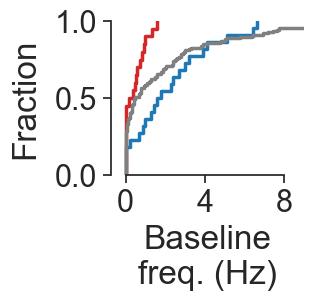

In [134]:
# Firing frequency

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2)
sns.set_style("ticks")

cum = sns.ecdfplot(
    data=ephys2,
    x="Firing_freq_(Hz)_I0",
    hue="Behaviour_6hFD",
    palette=triple_ff,
    linewidth=2.5,
    legend=False,
    stat="proportion",
)
cum.set_xlabel("Baseline\nfreq. (Hz)", labelpad=5)
cum.set_ylabel("Fraction", labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/ff.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

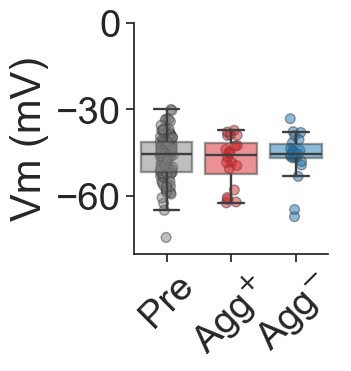

In [135]:
# Membrane voltage / RMP

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=triple,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Vm (mV)", labelpad=5)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-koheslj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Vm.pdf',
#             dpi=300,bbox_inch='tight', transparent=True)

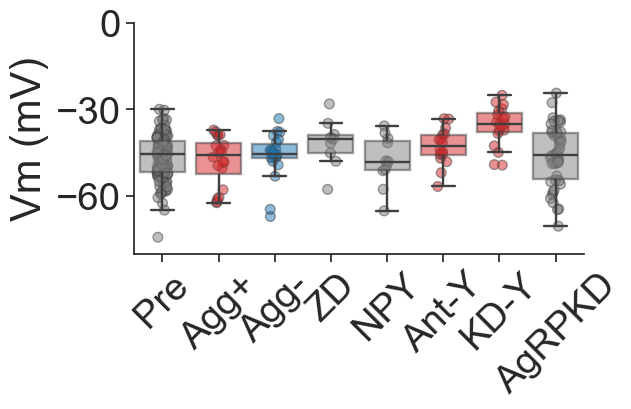

In [136]:
# Membrane voltage / RMP - VERSION WITH ALL GROUPS

sns.set(rc={"figure.figsize": (5.8, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys,
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npy_antag", "npykd", "agrpkd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=seven,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys,
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npy_antag", "npykd", "agrpkd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=seven,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Vm (mV)", labelpad=5)

ax.set_xticklabels(
    ("Pre", "Agg+", "Agg-", "ZD", "NPY", "Ant-Y", "KD-Y", "AgRPKD"), rotation=45
)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Vm_all.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

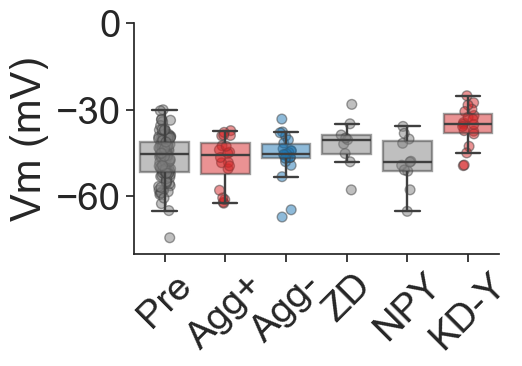

In [137]:
# Membrane voltage / RMP - VERSION WITH ALL GROUPS but w/o ANT

sns.set(rc={"figure.figsize": (4.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys,
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npykd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=six,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys,
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npykd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=six,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Vm (mV)", labelpad=5)

ax.set_xticklabels(("Pre", "Agg+", "Agg-", "ZD", "NPY", "KD-Y"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Vm_all_Y12.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

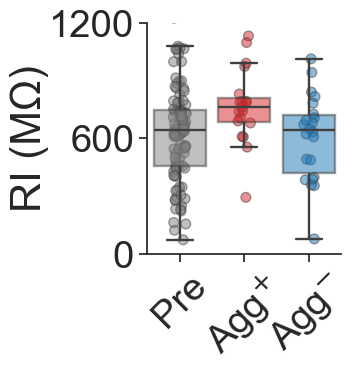

In [138]:
# Input resistance

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=triple,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("RI (MΩ)", labelpad=0)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1200)
sns.despine(bottom=False, trim=False)


# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ri.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

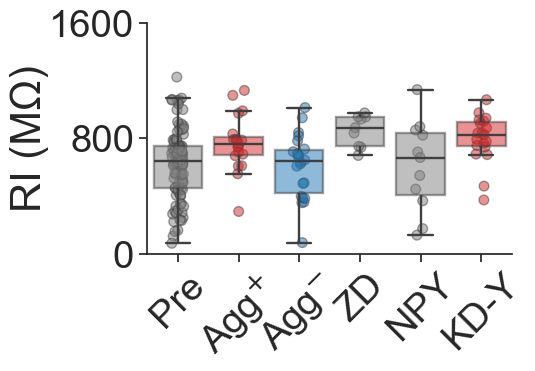

In [139]:
# Input resistance - VERSION WITH ALL GROUPS w/o Ant

sns.set(rc={"figure.figsize": (4.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys,
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npykd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=six,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys,
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npykd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=six,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("RI (MΩ)", labelpad=0)

ax.set_xticklabels(
    ("Pre", r"Agg$^{+}$", r"Agg$^{-}$", "ZD", "NPY", "KD-Y"), rotation=45
)

ax.yaxis.set_major_locator(plt.MaxNLocator(2))
plt.ylim(0, 1600)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ri_all_Y12.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

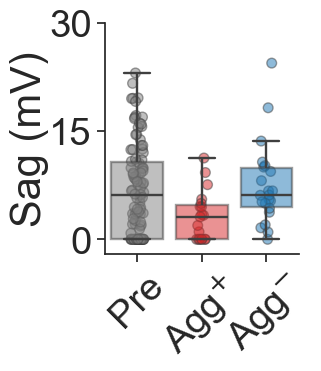

In [140]:
# Ih
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=triple,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Sag (mV)", labelpad=0)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)


# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

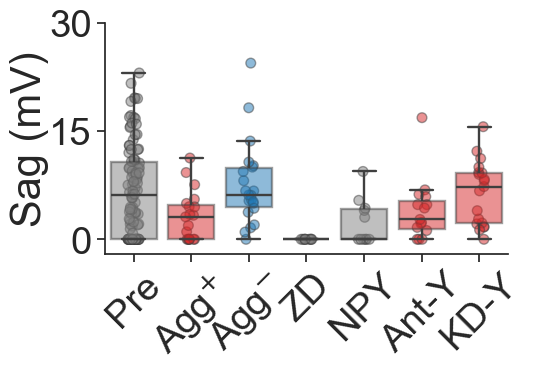

In [141]:
# Ih - VERSION WITH ALL GROUPS
sns.set(rc={"figure.figsize": (5.2, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys[(ephys.ID_mouse != "JKAJ37.6g")],
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npy_antag", "npykd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=seven,
    boxprops={"alpha": 0.5},
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys[(ephys.ID_mouse != "JKAJ37.6g")],
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npy_antag", "npykd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=seven,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Sag (mV)", labelpad=0)

ax.set_xticklabels(
    ("Pre", r"Agg$^{+}$", r"Agg$^{-}$", "ZD", "NPY", "Ant-Y", "KD-Y", "AgRPKD"),
    rotation=45,
)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig(
#     "/Volumes/la_inb-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_all.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

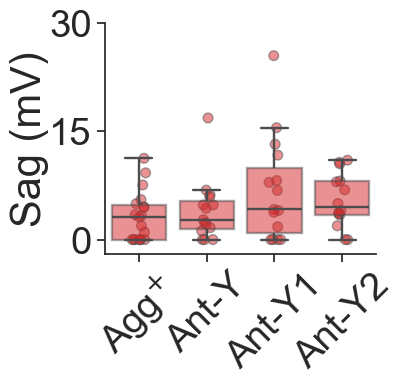

In [142]:
# Ih - VERSION WITH ALL GROUPS INCL Y1/2
sns.set(rc={"figure.figsize": (3.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys,
    order=["Agg+", "npy_antag", "npy1r_antag", "npy2r_antag"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=["Tab:red"],
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys,
    order=["Agg+", "npy_antag", "npy1r_antag", "npy2r_antag"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=["Tab:red"],
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Sag (mV)", labelpad=0)

ax.set_xticklabels((r"Agg$^{+}$", "Ant-Y", "Ant-Y1", "Ant-Y2"), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)


# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ih_all_Y12.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

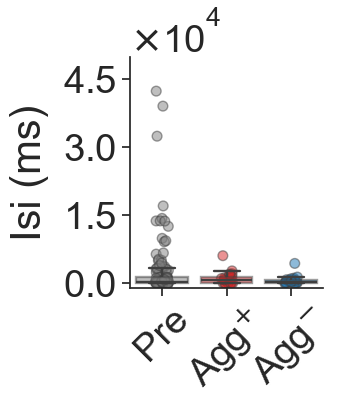

In [143]:
# Isi
from matplotlib.ticker import ScalarFormatter

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="isi_(ms)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="isi_(ms)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=triple,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Isi (ms)", labelpad=10)

# Set the y-axis to be in scientific notation
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))

# Use scientific notation for ticks
ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(-1000, 50000)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/isi.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

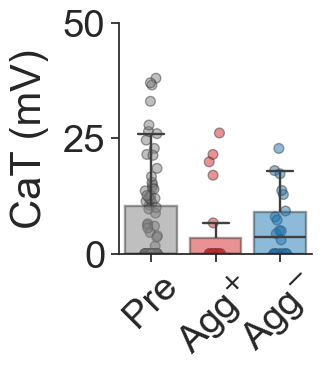

In [144]:
# CaT
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="CaT",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="CaT",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=triple,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("CaT (mV)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
plt.ylim(0, 50)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/cat.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

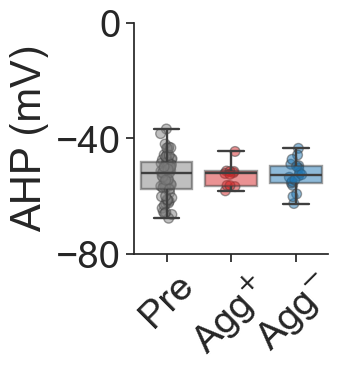

In [145]:
# AHP

ephys_filtered = ephys[ephys["AHP_(mV)"] != 0]

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="AHP_(mV)",
    data=ephys_filtered,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="AHP_(mV)",
    data=ephys_filtered,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=triple,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("AHP (mV)", labelpad=5)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
plt.ylim(-80, 0)
ax.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/ahp.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

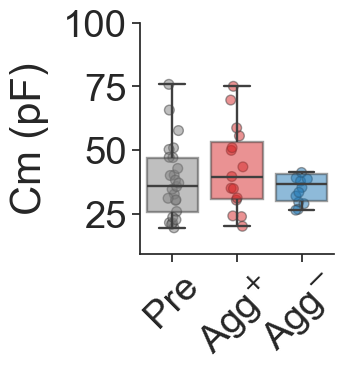

In [146]:
# Cm
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Cm(pF)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Cm(pF)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=0,
    palette=triple,
)
ax.set_xlabel("")
ax.set_ylabel("Cm (pF)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(top=100)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/Cm.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

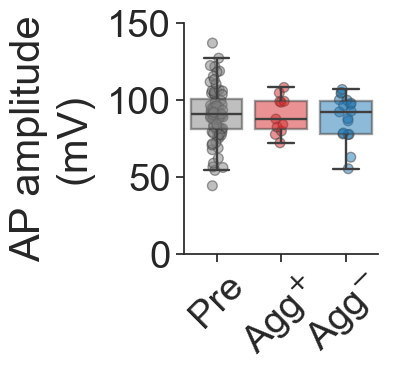

In [147]:
# AP_ampl
ephys_filt = ephys[ephys["AP_ampl"] != 0]

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="AP_ampl",
    data=ephys_filt,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="AP_ampl",
    data=ephys_filt,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=0,
    palette=triple,
)
ax.set_xlabel("")
ax.set_ylabel("AP amplitude\n(mV)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
plt.ylim(0, 150)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_ampl.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

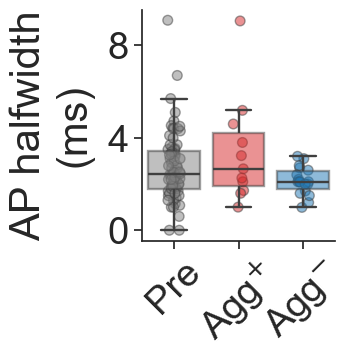

In [148]:
# AP_halfwidth
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")
non_silent = ephys[
    (~ephys["experiment_day"].str.contains("2025")) & (ephys.I_zero != "silent")
]

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="AP_halfwidth",
    data=non_silent,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="AP_halfwidth",
    data=non_silent,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=0,
    palette=triple,
)
ax.set_xlabel("")
ax.set_ylabel("AP halfwidth\n(ms)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
# plt.ylim(0,15)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_halfwidth.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

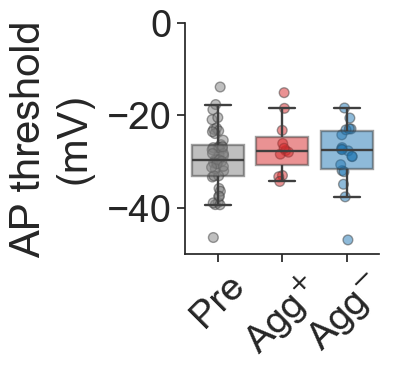

In [185]:
# AP threshold - loaded from a different excel sheet currently, but will add to main ephys.csv file
ap_thresh = pd.read_csv(
    "data/APthreshold_v1.csv"
)

sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="state",
    y="AP_threshold_mV",
    data=ap_thresh,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="state",
    y="AP_threshold_mV",
    data=ap_thresh,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=0,
    palette=triple,
)
ax.set_xlabel("")
ax.set_ylabel("AP threshold\n(mV)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-50, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/AP_threshold.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

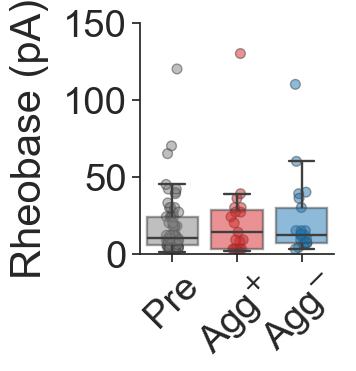

In [152]:
# rheobase_at_-60mV_(pA)
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="rheobase_at_-60mV_(pA)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="rheobase_at_-60mV_(pA)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=0,
    palette=triple,
)
ax.set_xlabel("")
ax.set_ylabel("Rheobase (pA)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 150)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/rheo.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

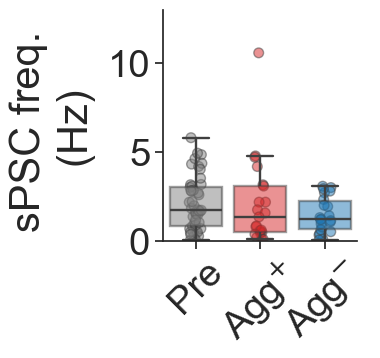

In [153]:
# sPSC_frequency
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="sPSC_frequency",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="sPSC_frequency",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=0,
    palette=triple,
)
ax.set_xlabel("")
ax.set_ylabel("sPSC freq. \n(Hz)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 13)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_freq.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

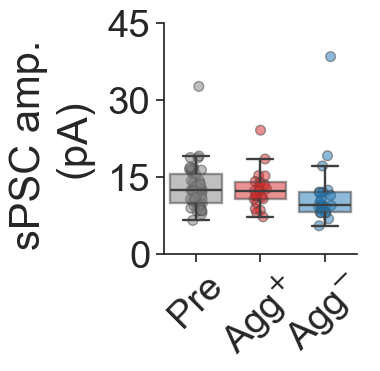

In [154]:
# sPSC_amp
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="sPSC_Amplitude(pA)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="sPSC_Amplitude(pA)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=0,
    palette=triple,
)
ax.set_xlabel("")
ax.set_ylabel("sPSC amp. \n(pA)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 45)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_amp.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

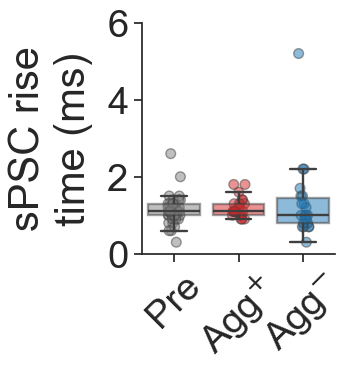

In [155]:
# sPSC rise time
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="sPSCs_Rise time",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="sPSCs_Rise time",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=0,
    palette=triple,
)
ax.set_xlabel("")
ax.set_ylabel("sPSC rise\ntime (ms)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 6)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_rise.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

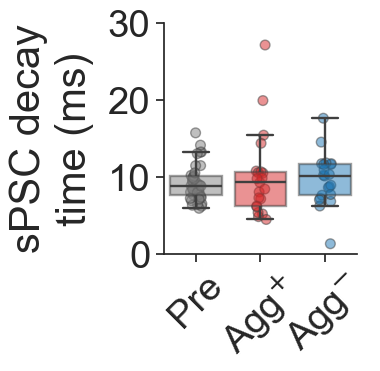

In [156]:
# sPSC decay time
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")


ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="sPSCs (decay)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=triple,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="sPSCs (decay)",
    data=ephys,
    order=["Pre", "Agg+", "Agg-"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=0,
    palette=triple,
)
ax.set_xlabel("")
ax.set_ylabel("sPSC decay\ntime (ms)", labelpad=10)

ax.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.5))

# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/sPSC_decay.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

In [157]:
# correlation between input resistance and Sag
trial = ephys[ephys.Behaviour_6hFD.isin(["Pre"])]
trial.dropna(subset=["Ih_at_-120mV", "Input_Resistance"], inplace=True)
print(trial.shape)
trial = trial.rename(
    columns={
        "Ih_at_-120mV": "ih_current",
        "Firing_freq_(Hz)_I0": "firing_freq",
        "sPSC_Amplitude(pA)": "sPSC_Amplitude",
    }
)

model = smf.ols("Input_Resistance ~  ih_current  ", data=trial).fit()
model.summary()

(102, 38)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       Input_Resistance   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     5.736
Date:                Sat, 18 Oct 2025   Prob (F-statistic):             0.0185
Time:                        19:19:58   Log-Likelihood:                -697.57
No. Observations:                 102   AIC:                             1399.
Df Residuals:                     100   BIC:                             1404.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    686.1192     33.423     20.528      0.000     619.809     752.430
ih_current    -8.7703      3.662     -2.395      0.018     -16.035      -1.505
==============================================================================
Omnibus:                        0.266   Durbin-Watson:                   1.471
Prob(Omnibus):                  0.876   Jarque-Bera (JB):                0.048
Skew:                           0.035   Prob(JB):                        0.976
Kurtosis:                       3.081   Cond. No.                         13.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

(-1.0, 24.0)

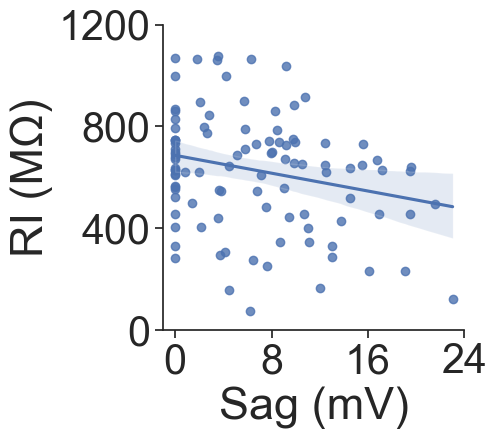

In [158]:
sns.set(font_scale=2.7)
sns.set_style("ticks")
sns.lmplot(
    x="ih_current",
    y="Input_Resistance",
    data=trial,
    palette=["darkgray", "#F97306", "blue"],
    aspect=1.1,
)
plt.ylabel("RI (MΩ)")
plt.xlabel("Sag (mV)")
plt.ylim(0, 1200)
plt.yticks([0, 400, 800, 1200])
plt.xticks([0, 8, 16, 24])
plt.xlim(-1, 24)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/ih_input_resistance.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

# Gal+ vs Gal-

In [159]:
df = pd.read_csv("data/ephys_analysis_MC_after_adding_BJ.csv")
gals = df[(df.Gal_positive.isin(["yes", "no"])) & (df.Behaviour_6hFD != "Pre")]

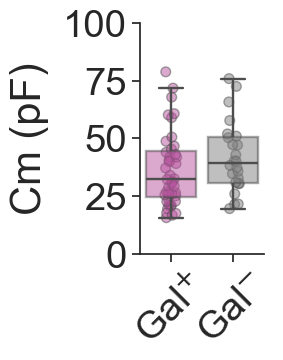

In [160]:
# Cm Gal+ vs Gal-
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Gal_positive",
    y="Cm(pF)",
    data=gals,
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=dual,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Gal_positive",
    y="Cm(pF)",
    data=gals,
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=1,
    palette=dual,
)
ax.set_xlabel("")
ax.set_ylabel("Cm (pF)", labelpad=10)

ax.set_xticklabels((r"Gal$^{+}$", r"Gal$^{-}$"), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 100)
sns.despine()


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Cm.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

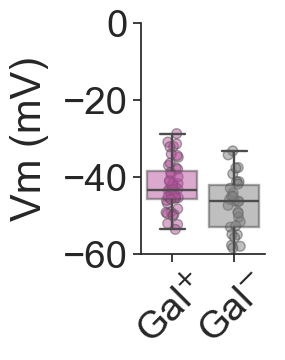

In [161]:
# Vm Gal+ vs Gal-
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Gal_positive",
    y="Vm",
    data=gals,
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=dual,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Gal_positive",
    y="Vm",
    data=gals,
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=1,
    palette=dual,
)
ax.set_xlabel("")
ax.set_ylabel("Vm (mV)", labelpad=10)

ax.set_xticklabels((r"Gal$^{+}$", r"Gal$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-60, 0)
sns.despine()


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Vm.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

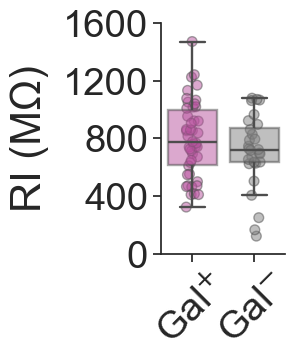

In [162]:
# RI Gal+ vs Gal-
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Gal_positive",
    y="Input_Resistance",
    data=gals,
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=dual,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Gal_positive",
    y="Input_Resistance",
    data=gals,
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=1,
    palette=dual,
)
ax.set_xlabel("")
ax.set_ylabel("RI (MΩ)", labelpad=10)

ax.set_xticklabels((r"Gal$^{+}$", r"Gal$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 1600)
sns.despine()


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Ri.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

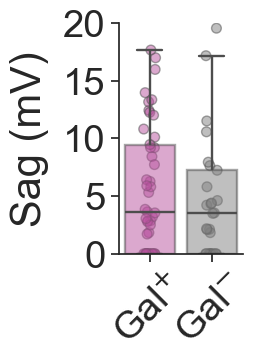

In [163]:
# Ih Gal+ vs Gal-
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Gal_positive",
    y="Ih_at_-120mV",
    data=gals,
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=dual,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Gal_positive",
    y="Ih_at_-120mV",
    data=gals,
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    alpha=0.5,
    zorder=1,
    palette=dual,
)
ax.set_xlabel("")
ax.set_ylabel("Sag (mV)", labelpad=10)

ax.set_xticklabels((r"Gal$^{+}$", r"Gal$^{-}$"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 20)
sns.despine()


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Ih.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

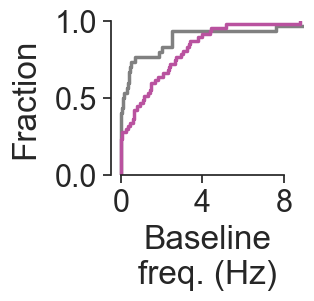

In [164]:
# Firing frequency Gal+ vs Gal-
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2)
sns.set_style("ticks")

cum = sns.ecdfplot(
    data=gals,
    x="Firing_freq_(Hz)_I0",
    hue="Gal_positive",
    palette=dual,
    linewidth=2.5,
    legend=False,
    stat="proportion",
)
cum.set_xlabel("Baseline\nfreq. (Hz)", labelpad=5)
cum.set_ylabel("Fraction", labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/ff.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

# Silent proportion

I_zero_reclassified  phasic  silent  tonic  All
Behaviour_6hFD                                 
Agg+                      6       9      5   20
Agg-                      4       4     14   22
Pre                      22      34     70  126
ZD7288                    0       8      1    9
agrp_100                  2       5      8   15
agrpkd                    7      14     22   43
npy1r_antag               2       3     10   15
npy2r_antag               3       6      6   15
npy_100                   2       7      2   11
npy_antag                 4       3      9   16
npykd                     3       5     11   19
All                      55      98    158  311
32.845445881470084 0.03508171662811909 20


Text(0.5, 1.0, 'silent_prop')

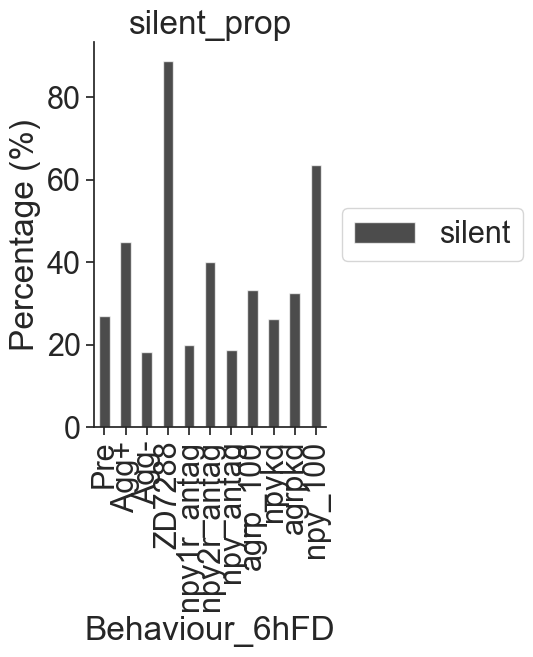

In [166]:
## silent proportion
cols = ["silent"]
cat = [
    "Pre",
    "Agg+",
    "Agg-",
    "ZD7288",
    "npy1r_antag",
    "npy2r_antag",
    "npy_antag",
    "agrp_100",
    "npykd",
    "agrpkd",
    "npy_100",
]
filtered_ephys = ephys[ephys.ID_mouse != "JKAJ37.6g"]

silent_prop = proportion(
    filtered_ephys[(filtered_ephys.Behaviour_6hFD.isin(cat))],
    "Behaviour_6hFD",
    "I_zero_reclassified",
    cols,
)
silent_prop["Behaviour_6hFD"] = pd.Categorical(silent_prop["Behaviour_6hFD"], cat)
silent_prop = silent_prop.sort_values(by=["Behaviour_6hFD"])
prop_plot(silent_prop, "Behaviour_6hFD")
plt.xticks(rotation=90)
plt.title("silent_prop")
# plt.savefig('output_figures/silent_prop.png',dpi = 300, bbox_inches = 'tight')

Text(0.5, 1.0, ' ')

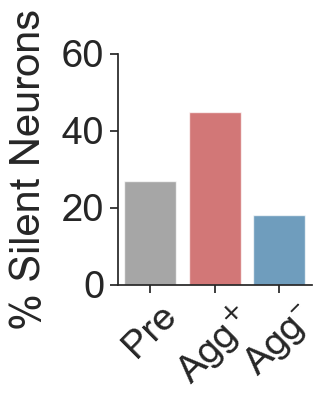

In [167]:
# % silent neurons
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_prop,
    x="Behaviour_6hFD",
    y="silent",
    order=["Pre", "Agg+", "Agg-"],
    palette=triple,
    alpha=0.7,
)
g.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylabel("% Silent Neurons", labelpad=10)
g.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{–}$"), rotation=45)
plt.xlabel("")
plt.ylim(0, 60)
sns.despine(bottom=False)
plt.title(" ", pad = 10)
# g.tick_params(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

In [168]:
silent_df = silent_prop.loc[:, ["Behaviour_6hFD", "silent"]]

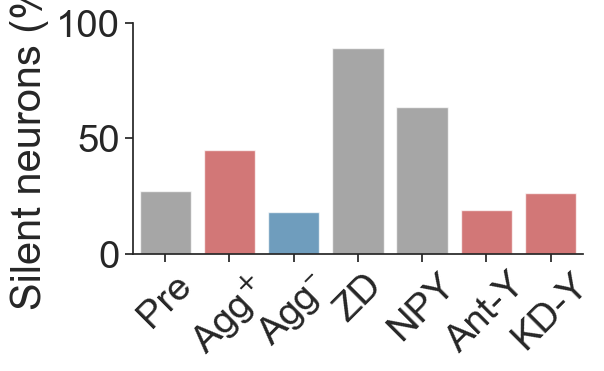

In [169]:
# % silent neurons - VERSION WITH ALL GROUPS
sns.set(rc={"figure.figsize": (5.8, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_prop,
    x="Behaviour_6hFD",
    y="silent",
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npy_antag", "npykd"],
    palette=seven,
    alpha=0.7,
)
plt.ylabel("Silent neurons (%)", labelpad=5)
g.set_xticklabels(
    ("Pre", r"Agg$^{+}$", r"Agg$^{–}$", "ZD", "NPY", "Ant-Y", "KD-Y"), rotation=45
)
plt.xlabel("")
plt.ylim(0, 100)
g.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop_all.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

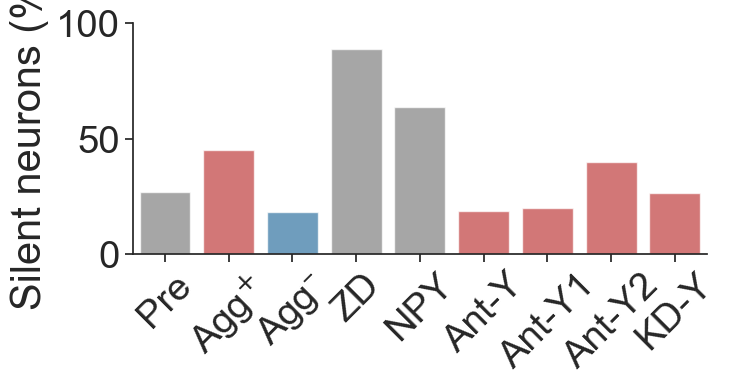

In [170]:
# % silent neurons - VERSION WITH ALL GROUPS INCL Y1/2
sns.set(rc={"figure.figsize": (7.4, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_prop,
    x="Behaviour_6hFD",
    y="silent",
    order=[
        "Pre",
        "Agg+",
        "Agg-",
        "ZD7288",
        "npy_100",
        "npy_antag",
        "npy1r_antag",
        "npy2r_antag",
        "npykd",
    ],
    palette=nine,
    alpha=0.7,
)
plt.ylabel("Silent neurons (%)", labelpad=5)
g.set_xticklabels(
    (
        "Pre",
        r"Agg$^{+}$",
        r"Agg$^{–}$",
        "ZD",
        "NPY",
        "Ant-Y",
        "Ant-Y1",
        "Ant-Y2",
        "KD-Y",
    ),
    rotation=45,
)
plt.xlabel("")
plt.ylim(0, 100)
g.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False)
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_prop_all_Y12.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

Text(0.5, 1.0, ' ')

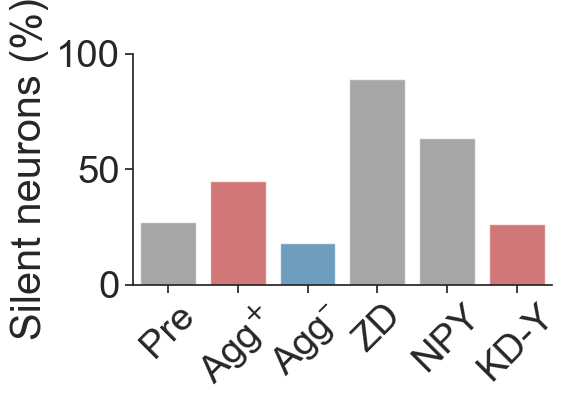

In [171]:
# % silent neurons - VERSION WITH ALL GROUPS but w/o Ant
sns.set(rc={"figure.figsize": (5.4, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")


g = sns.barplot(
    silent_prop,
    x="Behaviour_6hFD",
    y="silent",
    order=["Pre", "Agg+", "Agg-", "ZD7288", "npy_100", "npykd"],
    palette=six,
    alpha=0.7,
)
plt.ylabel("Silent neurons (%)", labelpad=5)
g.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{–}$", "ZD", "NPY", "KD-Y"), rotation=45)
plt.xlabel("")
plt.ylim(0, 100)
g.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False)
plt.title(" ", pad = 10)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_prop_all_Y12.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
#     pad_inches=0.5,
# )

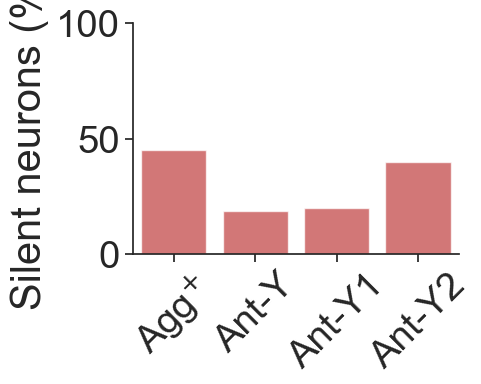

In [172]:
# % silent neurons - VERSION WITH ONLY ANT
sns.set(rc={"figure.figsize": (4.2, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_prop,
    x="Behaviour_6hFD",
    y="silent",
    order=["Agg+", "npy_antag", "npy1r_antag", "npy2r_antag"],
    palette=ant,
    alpha=0.7,
)
plt.ylabel("Silent neurons (%)", labelpad=5)
g.set_xticklabels((r"Agg$^{+}$", "Ant-Y", "Ant-Y1", "Ant-Y2"), rotation=45)
plt.xlabel("")
plt.ylim(0, 100)
g.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False)
# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_prop_ant.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
#     pad_inches=0.5,
# )

Text(0.5, 1.0, ' ')

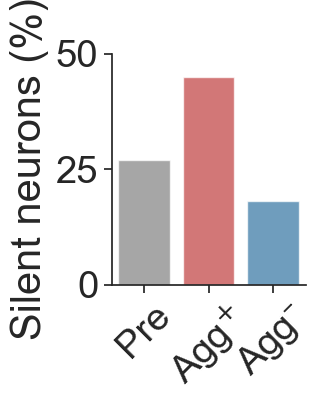

In [173]:
# % silent neurons - only Pre/Agg+/Agg-
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_prop,
    x="Behaviour_6hFD",
    y="silent",
    order=["Pre", "Agg+", "Agg-"],
    palette=triple,
    alpha=0.7,
)
plt.ylabel("Silent neurons (%)", labelpad=5)
g.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{–}$"), rotation=45)
plt.xlabel("")
plt.ylim(0, 50)
g.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False)
plt.title(" ", pad = 10)
# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop_short.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

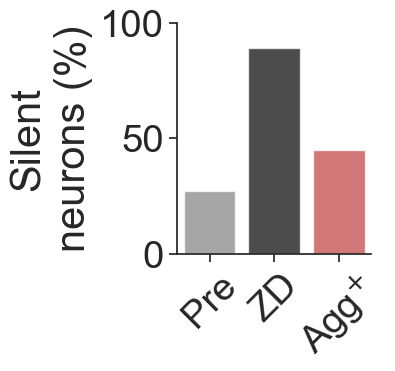

In [174]:
# % silent neurons - Pre/Agg+/ZD
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_prop,
    x="Behaviour_6hFD",
    y="silent",
    order=["Pre", "ZD7288", "Agg+"],
    palette=["gray", "black", "Tab:red"],
    alpha=0.7,
)
plt.ylabel("Silent\nneurons (%)", labelpad=5)
g.set_xticklabels(("Pre", "ZD", r"Agg$^{+}$"), rotation=45)
plt.xlabel("")
plt.ylim(0, 100)
g.yaxis.set_major_locator(plt.MaxNLocator(2))
sns.despine(bottom=False)
# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/silent_prop_ZD.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

I_zero        phasic  silent  tonic  All
Gal_positive                            
no                 3      12     15   30
yes                5      11     31   47
All                8      23     46   77
2.4761447733580018 0.28994257678952506 2


Text(0.5, 1.0, 'galanin_silent_prop')

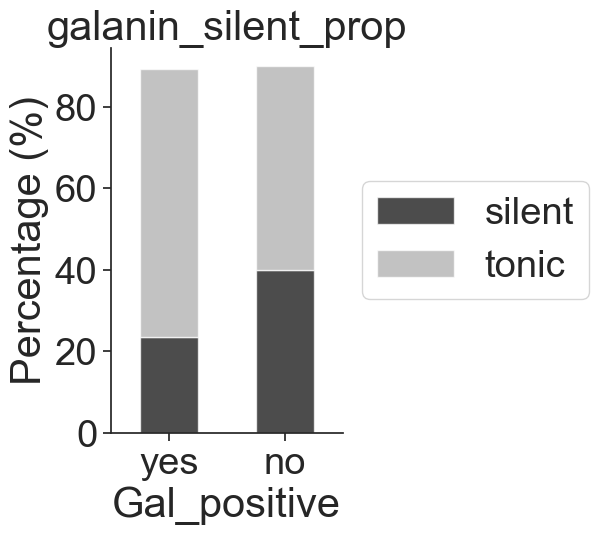

In [175]:
cols = ["silent", "tonic"]
silent_prop = proportion(gals, "Gal_positive", "I_zero", cols)
silent_prop["Gal_positive"] = pd.Categorical(silent_prop["Gal_positive"], ["yes", "no"])
silent_prop = silent_prop.sort_values(by=["Gal_positive"])
prop_plot(silent_prop, "Gal_positive")
plt.title("galanin_silent_prop")
# plt.savefig('output_figures/galanin_silent_prop.png',dpi = 300, bbox_inches = 'tight')

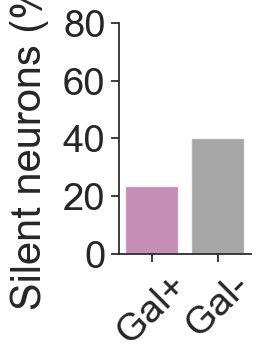

In [176]:
# % silent neurons
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_prop,
    x="Gal_positive",
    y="silent",
    order=["yes", "no"],
    palette=dual,
    alpha=0.7,
)
plt.ylabel("Silent neurons (%)", labelpad=10)
g.set_xticklabels(("Gal+", "Gal-"), rotation=45)
plt.xlabel("")
plt.ylim(0, 80)
g.yaxis.set_major_locator(plt.MaxNLocator(4))
sns.despine()
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/silent.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

# Adaptive prop (DB)

In [177]:
## adaptive proportion
cols = ["yes", "no"]
cat = [
    "Pre",
    "Agg+",
    "Agg-",
]
ad_prop = proportion(
    ephys[ephys.Behaviour_6hFD.isin(cat)], "Behaviour_6hFD", "Adaptive", cols
)
# ad_prop['Behaviour_6hFD'] = pd.Categorical(ad_prop['Behaviour_6hFD'], cat)
# ad_prop = ad_prop.sort_values(by = ['Behaviour_6hFD'])
# ad_prop

Adaptive        ?  no  yes  All
Behaviour_6hFD                 
Agg+            1   7   12   20
Agg-            0  18    3   21
Pre             1  25   32   58
All             2  50   47   99
14.321474268944554 0.006336665251566063 4


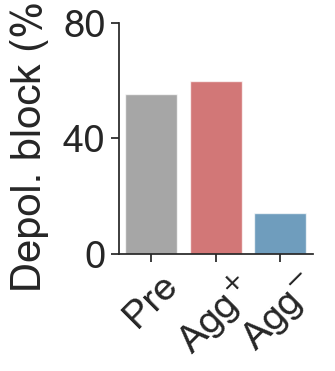

In [178]:
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    x="Behaviour_6hFD",
    y="yes",
    data=ad_prop,
    order=["Pre", "Agg+", "Agg-"],
    palette=triple,
    alpha=0.7,
)

plt.ylabel("Depol. block (%)", labelpad=10)
g.set_xticklabels(("Pre", r"Agg$^{+}$", r"Agg$^{-}$"), rotation=45)

plt.xlabel("")
plt.ylim(top=60)
plt.yticks(np.arange(0, 81, 40))
sns.despine(bottom=False)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/adaptive_prop.pdf',
# dpi=300,bbox_inches='tight', transparent=True)

Adaptive      ?  no  yes  All
Gal_positive                 
no            1   9   16   26
yes           0  14   30   44
All           1  23   46   70
1.8409851018546668 0.39832279849497015 2


Text(0.5, 1.0, 'galanin_adaptive_prop')

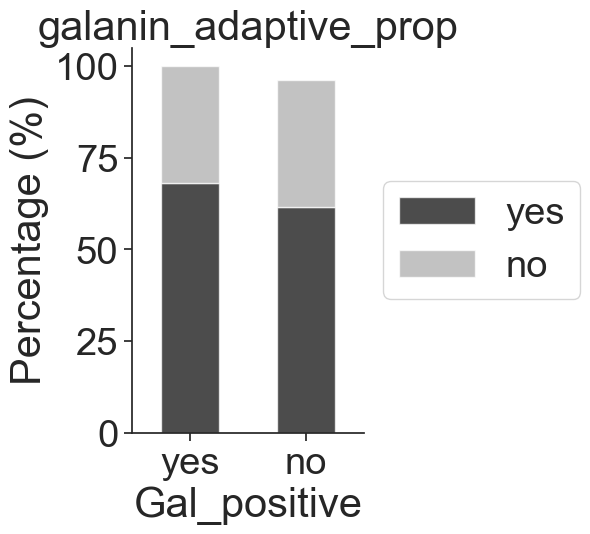

In [179]:
cols = ["yes", "no"]
ad_prop = proportion(gals, "Gal_positive", "Adaptive", cols)
ad_prop["Gal_positive"] = pd.Categorical(ad_prop["Gal_positive"], ["yes", "no"])
ad_prop = ad_prop.sort_values(by=["Gal_positive"])
prop_plot(ad_prop, "Gal_positive")
plt.title("galanin_adaptive_prop")
# plt.savefig('output_figures/galanin_adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

# Calcium T prop

cat_categ        no  no   yes  yes   All
Behaviour_6hFD                          
Agg+             14    0    5     0   19
Agg-              9    1   11     1   22
Pre              64    1   38     0  103
ZD7288            6    0    3     0    9
ZD7288_20         2    0    1     0    3
agrp_100         13    0    2     0   15
agrpkd           23    0   16     0   39
npy1r_antag       9    0    6     0   15
npy2r_antag       9    0    5     0   14
npy_10            7    1    2     0   10
npy_100           6    0    5     0   11
npy_antag        14    0    1     0   15
npykd            14    0    5     0   19
All             190    3  100     1  294
40.060383510097196 0.2947404070066253 36


Text(0.5, 1.0, 'CaT_prop')

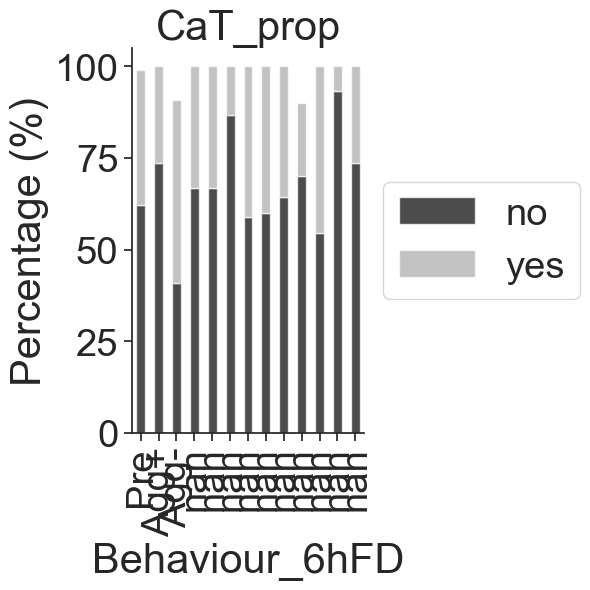

In [181]:
## calcium T proportion
cols = ["no", "yes"]
ca_prop = proportion(ephys, "Behaviour_6hFD", "cat_categ", cols)
ca_prop["Behaviour_6hFD"] = pd.Categorical(ca_prop["Behaviour_6hFD"], cat)
ca_prop = ca_prop.sort_values(by=["Behaviour_6hFD"])
prop_plot(ca_prop, "Behaviour_6hFD")
plt.xticks(rotation=90)

plt.title("CaT_prop")
# plt.savefig('output_figures/CaT_prop.png',dpi = 300, bbox_inches = 'tight')

cat_categ     no  yes  All
Gal_positive              
no            19   10   29
yes           25   21   46
All           44   31   75
0.5124373755204515 0.4740856342262889 1


Text(0.5, 1.0, 'galanin_CaT_prop')

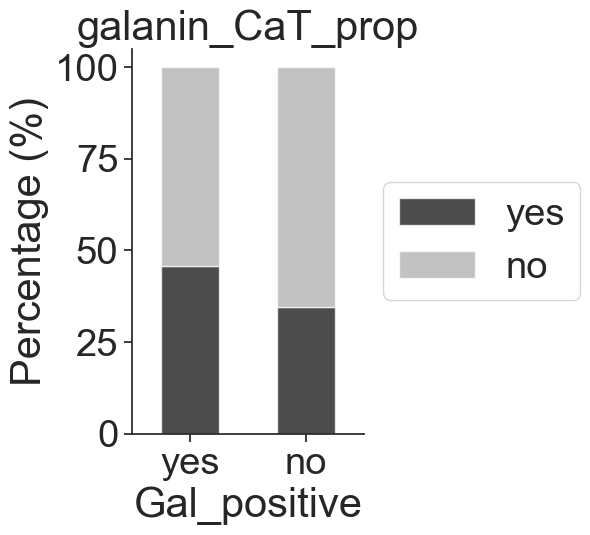

In [182]:
cols = ["yes", "no"]
ca_prop = proportion(gals, "Gal_positive", "cat_categ", cols)
ca_prop["Gal_positive"] = pd.Categorical(ca_prop["Gal_positive"], ["yes", "no"])
ca_prop = ca_prop.sort_values(by=["Gal_positive"])
prop_plot(ca_prop, "Gal_positive")

plt.title("galanin_CaT_prop")
# plt.savefig('output_figures/galanin_CaT_prop.png',dpi = 300, bbox_inches = 'tight')

# IH prop

IH              no  yes  All
Behaviour_6hFD              
Agg+             7   12   19
Agg-             1   21   22
Pre             28   75  103
ZD7288           9    0    9
ZD7288_20        3    0    3
agrp_100         6    9   15
agrpkd           3   36   39
npy1r_antag      4   11   15
npy2r_antag      2   12   14
npy_10           5    5   10
npy_100          6    5   11
npy_100_paired   2    1    3
npy_10_paired    0    5    5
npy_antag        3   12   15
npykd            1   18   19
All             80  222  302
65.65990508853565 1.1661465838130357e-08 14


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 [Text(0, 0, 'Pre'),
  Text(1, 0, 'Agg+'),
  Text(2, 0, 'Agg-'),
  Text(3, 0, 'nan'),
  Text(4, 0, 'nan'),
  Text(5, 0, 'nan'),
  Text(6, 0, 'nan'),
  Text(7, 0, 'nan'),
  Text(8, 0, 'nan'),
  Text(9, 0, 'nan'),
  Text(10, 0, 'nan'),
  Text(11, 0, 'nan'),
  Text(12, 0, 'nan'),
  Text(13, 0, 'nan'),
  Text(14, 0, 'nan')])

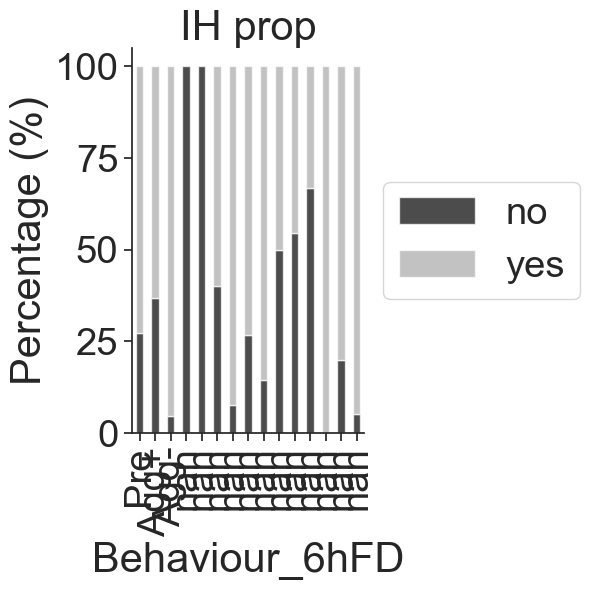

In [183]:
ephys.loc[(ephys["Ih_at_-120mV"] == 0), "IH"] = "no"
ephys.loc[(ephys["Ih_at_-120mV"] > 0), "IH"] = "yes"
cols = ["no", "yes"]

ca_prop = proportion(ephys, "Behaviour_6hFD", "IH", cols)
ca_prop["Behaviour_6hFD"] = pd.Categorical(ca_prop["Behaviour_6hFD"], cat)
ca_prop = ca_prop.sort_values(by=["Behaviour_6hFD"])
prop_plot(ca_prop, "Behaviour_6hFD")

plt.title("IH prop")
plt.xticks(rotation=90)
# plt.savefig('output_figures/IH_prop.png',dpi = 300, bbox_inches = 'tight')

IH                   no  yes  All
I_zero_reclassified              
phasic                9   41   50
silent               38   64  102
tonic                33  117  150
All                  80  222  302
9.47376293941 0.008765940455223272 2


Text(0.5, 0, '')

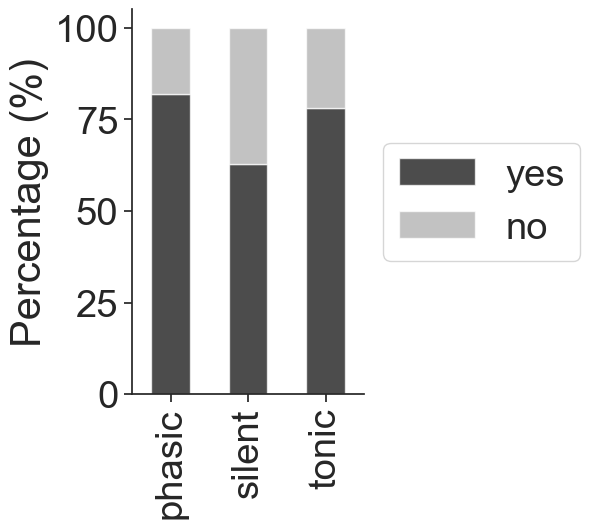

In [184]:
cols = ["yes", "no"]
ih_prop = proportion(ephys, "I_zero_reclassified", "IH", cols)
# ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ih_prop, "I_zero_reclassified")
plt.xticks(rotation=90)
plt.xlabel("")

# Ramp analysis (excitability)

In [89]:

df_state = pd.read_csv("data/ramps_all.csv")
states = [
    "Pre",
    "Agg+",
    "Agg-",
    "NPY 10nM",
    "NPY 100nM",
    "NPY Antag",
    "NPY1R",
    "NPY2R",
    "NPY-KD",
    "ZD7288",
    "Ramp_Agrp_KD",
]


df_all = process_df_state(df_state, states)
# estrous effect
df_state["filename"] = df_state["filename"].str.replace(".xlsx", "").str.upper()
estrous_df = process_df_state(df_state, states)

ephys = pd.read_csv("data/sampled_ephys_data_after_adding_BJ.csv")
ephys.rename(columns={"experiment_day": "filename"}, inplace=True)
ephys["filename"] = ephys["filename"].str.upper()
estrous_df = estrous_df.merge(
    ephys.loc[:, ["filename", "estrous_stage"]],
    on="filename",
    how="left",
)
estrous_df.loc[estrous_df.estrous_stage == "P<E", "estrous_stage"] = "E"
estrous_df.rename(columns={"I_Injected(pA)": "Injected"}, inplace=True)

In [90]:
sns.set(font_scale=2.5)
sns.set_style("ticks")

prop = "num_spike"

plot_df = df_all[df_all.state.isin(["Pre", "Agg+", "Agg-"])]

plot_df = plot_df[
    ~plot_df.filename.str.contains("2025")
]  # exclude 2025 data, just take rachida's data to ensure result integrity


In [91]:
combos = [
    ["Pre", "Agg+"],
    ["Pre", "Agg-"],
    ["Agg+", "Agg-"],
]
result_df = test_interaction_pvalues(
    plot_df, prop, combos, state_col="state", group_var="filename", correction=True
)

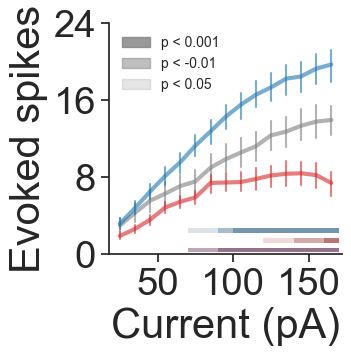

In [92]:
# overall pre, agg+, agg- comparison
fig, ax = plt.subplots(figsize=[3, 3])

palette = ["gray", "Tab:red", "Tab:blue"]
color = {"Pre": "gray", "Agg+": "tab:red", "Agg-": "tab:blue"}
combos = [
    ("Agg+", "Agg-"),
    ("Pre", "Agg+"),
    ("Pre", "Agg-"),
]

sns.lineplot(
    data=plot_df,
    x="Injected",
    y=prop,
    hue="state",
    palette=palette,
    err_style="bars",
    ci=58,
    linewidth=3,
    alpha=0.6,
    ax=ax,
)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
plt.ylim(0, 24)
ax.set_yticks([0, 8, 16, 24])
sns.despine(bottom=False)


plot_significance_bars_shifted(
    ax, plot_df, result_df, combos, color, base_y=1.2, y_shift=1
)

# plt.savefig(
#     f"/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{prop}.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )
plt.show()

In [93]:
# estrous effect (P, E, M, D)
df_state["filename"] = df_state["filename"].str.replace(".xlsx", "").str.upper()
estrous_df = process_df_state(df_state, ["Pre"])

ephys.rename(columns={"experiment_day": "filename"}, inplace=True)
ephys["filename"] = ephys["filename"].str.upper()
estrous_df = estrous_df[estrous_df.state == "Pre"].merge(
    ephys[ephys["Behaviour_6hFD"] == "Pre"].loc[
        :, ["filename", "estrous_stage", "ID_mouse", "Ih_at_-120mV"]
    ],
    on="filename",
    how="left",
)
estrous_df.loc[estrous_df.estrous_stage == "P<E", "estrous_stage"] = "E"
estrous_df.rename(columns={"I_Injected(pA)": "Injected"}, inplace=True)

Text(0.5, 1.0, ' ')

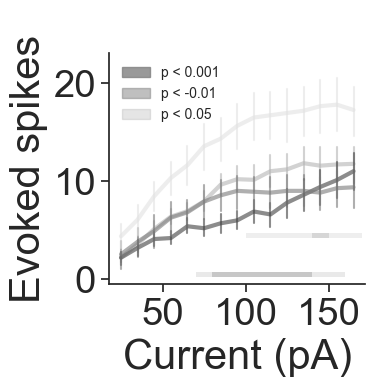

In [94]:
prop = "num_spike"
estrous_df.loc[estrous_df.filename == "S2C1 24072023", "estrous_stage"] = "E"
plot_df = estrous_df[
    (estrous_df.estrous_stage.isin(["P", "E", "M", "D"])) & (estrous_df.state == "Pre")
].dropna(subset=["estrous_stage", "Ih_at_-120mV", "Injected", prop])

estrous_combos = [
    ("P", "D"),
    ("P", "E"),
    ("P", "M"),
    ("E", "M"),
    ("E", "D"),
    ("M", "D"),
]
result_df = test_interaction_pvalues(
    plot_df,
    prop,
    estrous_combos,
    state_col="estrous_stage",
    group_var="filename",
    correction=True,
)

# generate palette for estrous stages from grays

levels = np.linspace(0.2, 0.8, 4)  # avoid 0 (black) and 1 (white)

# Use 'Greys' colormap
cmap = cm.get_cmap("Greys")

# Get colors
gray_palette = [cmap(l) for l in levels]

palettes = {
    "P": gray_palette[-1],
    "E": gray_palette[-2],
    "M": gray_palette[-3],
    "D": gray_palette[-4],
}

fig, ax = plt.subplots(figsize=[3.3, 3])
sns.lineplot(
    data=plot_df,
    x="Injected",
    y=prop,
    hue="estrous_stage",
    palette=palettes,
    err_style="bars",
    ci=58,
    linewidth=3,
    alpha=0.6,
)
# sns.stripplot(data=plot_df, x="Injected", y=prop, hue = 'estrous_stage', palette=palette, dodge=True, size=5, alpha=0.5)

ax.set_ylabel("Evoked spikes")

ax.set_xlabel("Current (pA)")
plt.ylim(-0.5, 23)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), title="Estrous stage")
sns.despine()
plot_significance_bars_shifted(
    ax,
    plot_df,
    result_df,
    estrous_combos,
    palettes,
    state_col="estrous_stage",
    base_y=1.2,
    y_shift=1,
)
plt.title(" ", pad=10)
# plt.savefig(
#     f"/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/estrous_excitability.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

In [95]:
variable = "num_spike"
x_variable = "Ih_at_-120mV"
formula = f'Q("{variable}") ~ Q("{x_variable}") '
plot_df["ID_mouse"] = plot_df["ID_mouse"].astype(str)

stats_df = plot_df[plot_df["Injected"] == 165].dropna(
    subset=["ID_mouse", "Ih_at_-120mV"]
)
model = smf.mixedlm(formula, data=stats_df, groups=stats_df["ID_mouse"]).fit()
print(model.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Q("num_spike")
No. Observations: 50      Method:             REML          
No. Groups:       18      Scale:              83.9468       
Min. group size:  1       Log-Likelihood:     -180.1802     
Max. group size:  7       Converged:          Yes           
Mean group size:  2.8                                       
------------------------------------------------------------
                    Coef. Std.Err.   z   P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept           9.338    1.878 4.973 0.000  5.658 13.019
Q("Ih_at_-120mV")   0.547    0.216 2.536 0.011  0.124  0.970
Group Var           0.000    1.284                          



## investigate ramp correlation

In [96]:
grouped_df = (
    plot_df.groupby("ID_mouse")
    .agg(
        {
            "num_spike": "mean",
            "estrous_stage": "first",
            "Ih_at_-120mV": "mean",
        }
    )
    .reset_index()
)

In [97]:
variable = "num_spike"
x_variable = "Ih_at_-120mV"
formula = f'Q("{variable}") ~ Q("{x_variable}") '


model = smf.ols(
    formula,
    data=grouped_df,
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Q("num_spike")   R-squared:                       0.274
Model:                            OLS   Adj. R-squared:                  0.228
Method:                 Least Squares   F-statistic:                     6.031
Date:                Sat, 18 Oct 2025   Prob (F-statistic):             0.0259
Time:                        16:13:42   Log-Likelihood:                -55.019
No. Observations:                  18   AIC:                             114.0
Df Residuals:                      16   BIC:                             115.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             5.1336      2.32

([<matplotlib.axis.YTick at 0x3222bd010>,
 [Text(0, 0, '0'), Text(0, 12, '12'), Text(0, 24, '24'), Text(0, 36, '36')])

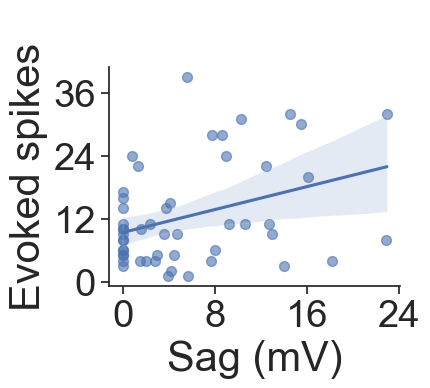

In [98]:
sns.lmplot(
    data=stats_df,
    x=x_variable,
    y=variable,
    height=4,
    aspect=1.2,
    scatter_kws={"alpha": 0.6, "s": 50},
)
plt.xlabel("Sag (mV)")
plt.ylabel("Evoked spikes")
plt.title(" ", pad=20)
plt.xticks([0, 8, 16, 24])
plt.yticks([0, 12, 24, 36])
# plt.savefig(
#      '/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/corr_sag_excitability_all.pdf',
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

([<matplotlib.axis.YTick at 0x3227ebb50>,
 [Text(0, 0, '0'), Text(0, 10, '10'), Text(0, 20, '20'), Text(0, 30, '30')])

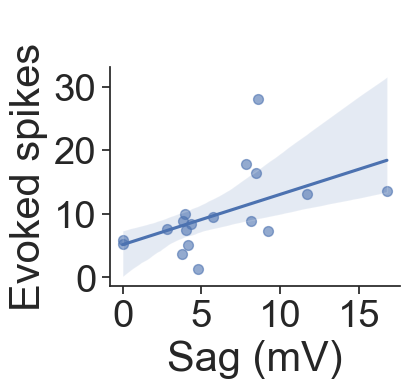

In [99]:
sns.lmplot(
    data=grouped_df,
    x=x_variable,
    y=variable,
    palette=palettes,
    height=4,
    aspect=1.2,
    scatter_kws={"alpha": 0.6, "s": 50},
)
plt.xlabel("Sag (mV)")
plt.ylabel("Evoked spikes")
plt.title(" ", pad=20)
plt.xticks([0, 5, 10, 15])
plt.yticks([0, 10, 20, 30])
# plt.savefig(
#      '/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_5/linked_figure_S5/corr_sag_excitability.pdf',
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

## pharmacology and manipulation ramp

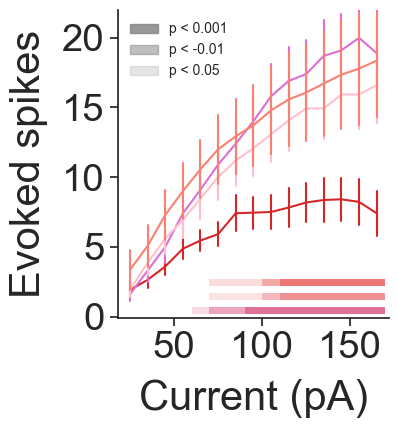

In [100]:
prop = "num_spike"

# generate random number of colors
combos = [("Agg+", "NPY Antag"), ("Agg+", "NPY1R"), ("Agg+", "NPY2R")]
result_df = test_interaction_pvalues(
    df_all, prop, combos, state_col="state", group_var="filename", correction=True
)

plot_df = df_all[df_all.state.isin(["Agg+", "NPY Antag", "NPY1R", "NPY2R"])]
fig, ax = plt.subplots(figsize=[3.5, 4])


colors = {
    "Pre": "gray",
    "Agg+": "Tab:red",
    "Agg-": "Tab:blue",
    "ZD7288": "black",
    "NPY-KD": "#8F3B5A",
    "NPY Antag": "orchid",
    "NPY1R": "pink",
    "NPY2R": "salmon",
    "NPY 10nM": "orchid",
    "NPY 100nM": "pink",
    "Ramp_Agrp_KD": "black",
}


sns.lineplot(
    data=plot_df,
    x="Injected",
    y=prop,
    hue="state",
    palette=colors,
    err_style="bars",
    errorbar=("se", 1),
)


# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.legend_.remove()

sns.despine()
plt.xlabel("Current (pA)", labelpad=10, fontsize=30)
plt.ylabel("Evoked spikes", labelpad=10, fontsize=30)

plot_significance_bars_shifted(
    ax, plot_df, result_df, combos, colors, state_col="state", base_y=1.2, y_shift=1
)
plt.ylim(-0.1, 22)
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
# plt.savefig(
#     f"/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/{prop}_antag.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

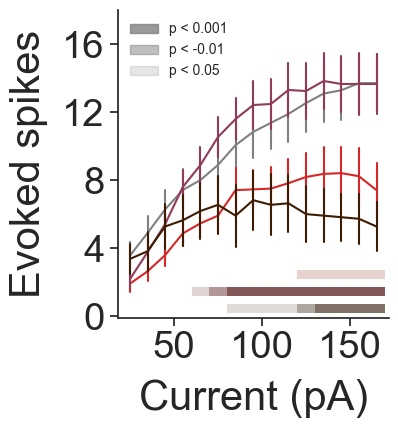

In [102]:
prop = "num_spike"

# generate random number of colors
combos = [
    ("ZD7288", "Pre"),
    ("ZD7288", "NPY-KD"),
    ("ZD7288", "Agg+"),
]


result_df = test_interaction_pvalues(
    df_all, prop, combos, state_col="state", group_var="filename", correction=True
)

plot_df = df_all[df_all.state.isin(["ZD7288", "Pre", "Agg+", "NPY-KD"])]
plot_df = plot_df[~plot_df.filename.str.contains("062025")]
fig, ax = plt.subplots(figsize=[3.5, 4])


colors = {
    "Pre": "gray",
    "Agg+": "Tab:red",
    "Agg-": "Tab:blue",
    "ZD7288": "#3D1c02",
    "NPY-KD": "#8F3B5A",
    "NPY Antag": "orchid",
    "NPY1R": "pink",
    "NPY2R": "salmon",
    "NPY 10nM": "orchid",
    "NPY 100nM": "pink",
    "Ramp_Agrp_KD": "black",
}


sns.lineplot(
    data=plot_df,
    x="Injected",
    y=prop,
    hue="state",
    palette=colors,
    err_style="bars",
    errorbar=("se", 1),
)


# ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.legend_.remove()

sns.despine()
plt.xlabel("Current (pA)", labelpad=10, fontsize=30)
plt.ylabel("Evoked spikes", labelpad=10, fontsize=30)

plt.ylim(-0.1, 18)
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
plot_significance_bars_shifted(
    ax, plot_df, result_df, combos, colors, state_col="state", base_y=1.2, y_shift=1
)

# plt.savefig(
#     f"/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Pre_Agg+_KD_ZD_pharma.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

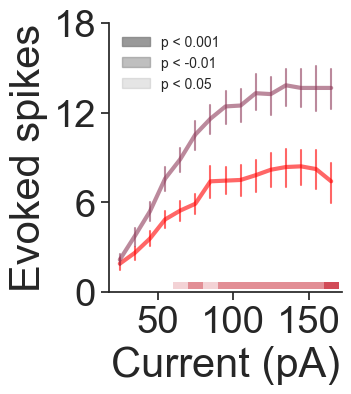

In [103]:
# only Agg+ and KD-Y

result_df = test_interaction_pvalues(
    df_all,
    prop,
    [("Agg+", "NPY-KD")],
    state_col="state",
    group_var="filename",
    correction=True,
)


sns.set(font_scale=2.5)
sns.set_style("ticks")

plot_df3 = df_all[df_all.state.isin(["Agg+", "NPY-KD"])]
fig, ax = plt.subplots(figsize=[3, 3.5])

typ = "Agg+_KD"
colors = {
    "Pre": "gray",
    "Agg+": "red",
    "ZD7288": "black",
    "NPY-KD": "#8F3B5A",
    "NPY Antag": "lightcoral",
    "NPY 10nM": "orange",
    "Agg-": "blue",
}
sns.lineplot(
    data=plot_df3,
    x="Injected",
    y=prop,
    hue="state",
    hue_order=["Agg+", "NPY-KD"],
    palette=["red", "#8F3B5A"],
    err_style="bars",
    ci=58,
    linewidth=3,
    alpha=0.6,
)


leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
ax.set_yticks([0, 6, 12, 18])
sns.despine(bottom=False)

plot_significance_bars_shifted(
    ax,
    plot_df3,
    result_df,
    [("Agg+", "NPY-KD")],
    colors,
    state_col="state",
    base_y=1.2,
    y_shift=1,
)

# plt.savefig(
#     f"/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{typ}_pharma.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

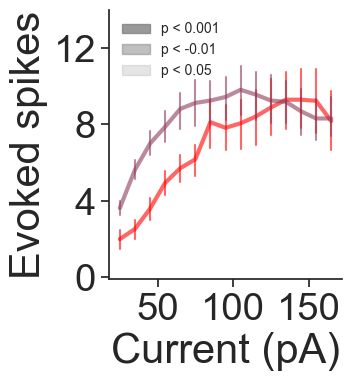

In [104]:
# only Agg+ and KD-A


sns.set(font_scale=2.5)
sns.set_style("ticks")

df_all = process_df_state(df_state, states)
plot_df3 = df_all[df_all.state.isin(["Agg+", "Ramp_Agrp_KD"])]
merged_agrpkd = pd.merge(plot_df3, ephys, on="filename", how="left")

merged_agrpkd = merged_agrpkd[merged_agrpkd.aggressive == "yes"]

result_df = test_interaction_pvalues(
    merged_agrpkd,
    prop,
    [("Agg+", "Ramp_Agrp_KD")],
    state_col="state_x",
    group_var="filename",
    correction=True,
)

fig, ax = plt.subplots(figsize=[3, 3.5])

sns.lineplot(
    data=merged_agrpkd,
    x="Injected",
    y=prop,
    hue="state_x",
    hue_order=["Agg+", "Ramp_Agrp_KD"],
    palette=["red", "#8F3B5A"],
    err_style="bars",
    ci=58,
    linewidth=3,
    alpha=0.6,
)

leg = ax.get_legend()
if leg:
    leg.remove()

ax.set_ylabel("Evoked spikes")
ax.set_xlabel("Current (pA)")
ax.set_yticks([0, 4, 8, 12])
plt.ylim(-0.1, 14)
sns.despine(bottom=False)
plot_significance_bars_shifted(
    ax,
    merged_agrpkd,
    result_df,
    [("Agg+", "Ramp_Agrp_KD")],
    {"Agg+": "red", "Ramp_Agrp_KD": "#8F3B5A"},
    state_col="state_x",
    base_y=1.2,
    y_shift=1,
)

# plt.savefig(
#     f"/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/agrpkd_excitability.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

# Estrous cycle influence

I_zero_reclassified  phasic  silent  tonic  All
estrous_stage                                  
D                         5       9     19   33
E                         2       3      3    8
M                         4       9     17   30
P                         8       8     17   33
All                      19      29     56  104
2.453166419182753 0.873671827775044 6
I_zero_reclassified  phasic  silent  tonic  All
estrous_stage                                  
D                         2       5      3   10
E                         3       1      0    4
P                         1       3      2    6
All                       6       9      5   20
5.1000000000000005 0.27718991430409357 4


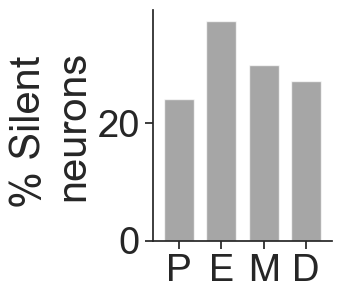

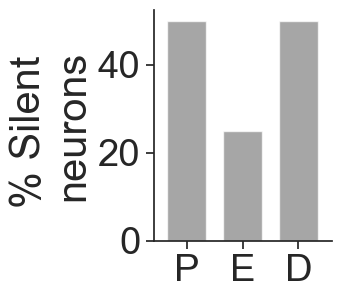

In [105]:
# silent proportion
ephys = pd.read_csv("data/sampled_ephys_data.csv")
ephys = ephys[ephys.experiment_day.str.contains("2025") == False]


ephys = ephys[
    ephys.I_zero_reclassified.isin(["silent", "phasic", "tonic"])
]  # was previously I_zero...
ephys.loc[(ephys["estrous_stage"] == "P to E"), "estrous_stage"] = "P"
ephys.loc[(ephys["estrous_stage"] == "D to P"), "estrous_stage"] = "D"
cols = ["silent", "phasic", "tonic"]
ephys.loc[ephys.Behaviour_6hFD.isin(["Agg+"]), "Behaviour_6hFD"] = "Post"

for state in ["Pre", "Post"]:
    state_df = ephys[ephys.Behaviour_6hFD == state]
    state_df = state_df[state_df.estrous_stage.isin(["P", "E", "M", "D"])]
    silent_prop = proportion(state_df, "estrous_stage", "I_zero_reclassified", cols)
    silent_prop["estrous_stage"] = pd.Categorical(
        silent_prop["estrous_stage"], ["P", "E", "M", "D"]
    )
    silent_prop = silent_prop.sort_values(by=["estrous_stage"])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(["P", "E", "M", "D"])]

    silent_prop.plot(
        x="estrous_stage",
        y="silent",
        kind="bar",
        stacked=True,
        mark_right=False,
        color=["gray"],
        figsize=(2.3, 3),
        alpha=0.7,
        width=0.7,
    )

    plt.xticks(rotation=0)
    ax = plt.gca()
    plt.ylabel("% Silent \nneurons")
    plt.xlabel("")
    ax.legend_.remove()
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    #     plt.title(f'{state}_silent_prop')
    # plt.savefig(f"output_figures/{state}_silent_prop.png", dpi=300, bbox_inches="tight")
    # plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/silent_estrous_{state}.pdf',
    #             dpi=300,bbox_inches='tight', transparent=True)

1.2361923955255694 0.3215637170184157 Cm(pF)
24 21
0.2878889741714546 0.8340483900804636 Firing_freq_(Hz)_I0
125 122
0.25894818097204453 0.8547947162302367 Instant_freq_(Hz)
125 122
1.125290367261745 0.3448255959594461 isi_(ms)
90 87
1.4862079549816152 0.22382303006762233 CaT
101 98
4.3138858156550715 0.006887169319263948 Ih_at_-120mV
102 99
estrous_stage
P    10
E     3
M     8
D     5
Name: ID_mouse, dtype: int64
Ih_at_-120mV 0.006887169319263948
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     D      E  -0.2242 0.9997  -6.6317  6.1834  False
     D      M  -5.5149 0.0062  -9.8083 -1.2214   True
     D      P   -1.659 0.7331  -5.8816  2.5636  False
     E      M  -5.2907 0.1394 -11.6721  1.0907  False
     E      P  -1.4348 0.9339  -7.7688  4.8991  False
     M      P   3.8559 0.0818  -0.3269  8.0386  False
-----------------------------------------------------


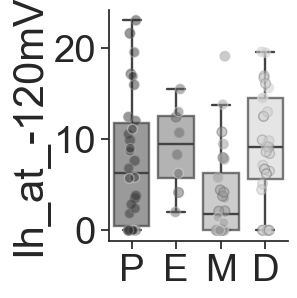

0.5427792566415147 0.6547407980659504 AP_ampl
75 72
1.6545729281433825 0.1858317551361428 AP_halfwidth
73 70
1.2287780275429816 0.30655300393240953 AP_time_to_peak
74 71
0.40821179037406796 0.7474620740455884 area(mV_ms)
107 104
0.43801429990433294 0.7265915464159713 rheobase_at_-60mV_(pA)
71 68
0.4026881058092993 0.7515466537250048 AHP_(mV)
74 71
0.2297240668112145 0.8754979676605967 Vm
124 121
1.098372535328157 0.3541500091392422 Input_Resistance
102 99
2.2031788961949506 0.10307979886912275 sPSC_frequency
44 41
1.2479070945120485 0.305939531285711 sPSC_Amplitude(pA)
43 40
0.7208157464356364 0.5463194578147716 sPSCs_Rise time
40 37
0.3711065461281537 0.7743494500519023 sPSCs (decay)
38 35
0.2 0.8886328452859166 AC-I0
4 1
nan nan AC_-60
4 1


In [108]:
# IH current
ls = [
    "Cm(pF)",
    "Firing_freq_(Hz)_I0",
    "Instant_freq_(Hz)",
    "isi_(ms)",
    "CaT",
    "Ih_at_-120mV",
    "AP_ampl",
    "AP_halfwidth",
    "AP_time_to_peak",
    "area(mV_ms)",
    "rheobase_at_-60mV_(pA)",
    "AHP_(mV)",
    "Vm",
    "Input_Resistance",
    "sPSC_frequency",
    "sPSC_Amplitude(pA)",
    "sPSCs_Rise time",
    "sPSCs (decay)",
    "AC-I0",
    "AC_-60",
]

sns.set(font_scale=2.5)
sns.set_style("ticks")

for state in ["Pre"]:  # change Pre/Post accordingly!
    for column in ls:
        # state_df = ephys[ephys.Behaviour_6hFD == state]
        state_df = ephys.copy()
        state_df["estrous_stage"] = pd.Categorical(
            state_df["estrous_stage"], ["P", "E", "M", "D"]
        )
        state_df = state_df[state_df.Behaviour_6hFD == state]

        if "AP" in column or "AHP" in column or "isi" in column:
            state_df = state_df[state_df["I_zero_reclassified"] != "silent"]

        try:

            stat, p = stats.f_oneway(
                state_df[column][state_df["estrous_stage"] == "P"].dropna(),
                state_df[column][state_df["estrous_stage"] == "E"].dropna(),
                state_df[column][state_df["estrous_stage"] == "M"].dropna(),
                state_df[column][state_df["estrous_stage"] == "D"].dropna(),
            )
            print(stat, p, column)

            dof_total = len(state_df[column].dropna()) - 1
            dof_within = dof_total - (state_df["estrous_stage"].nunique() - 1)
            print(dof_total, dof_within)

            # print(
            #     column,
            #     state_df.dropna(subset=[column])
            #     .groupby("estrous_stage")
            #     .experiment_day.nunique(),
            # )

            # print(column,
            #         state_df.dropna(subset=[column])
            #         .groupby("estrous_stage")
            #         .ID_mouse.nunique(),)
            if p < 0.05:
                print(state_df.groupby("estrous_stage")["ID_mouse"].nunique())
                print(column, p)
                state_df = state_df.loc[:, ["estrous_stage", column]].dropna()
                multiple_comp_result = pairwise_tukeyhsd(
                    endog=state_df[column], groups=state_df["estrous_stage"], alpha=0.05
                )
                print(multiple_comp_result.summary())

                fig, ax = plt.subplots(figsize=(2.3, 3))


                sns.boxplot(
                        x="estrous_stage",
                        y=column,
                        data=state_df,
                        order=["P", "E", "M", "D"],
                        saturation=8,
                        linewidth=1.7,
                        showfliers=False,
                        palette=["#707070", "#939393", "#B7B7B7", "#DBDBDB"],
                        boxprops=dict(alpha=0.7),
                    )
                sns.stripplot(
                        x="estrous_stage",
                        y=column,
                        data=state_df,
                        order=["P", "E", "M", "D"],
                        jitter=True,
                        dodge=False,
                        marker="o",
                        size=7,
                        linewidth=1,
                        edgecolor=["#707070", "#939393", "#B7B7B7", "#DBDBDB"],
                        palette="gray",
                        alpha=0.5,
                    )
                sns.despine()
    
                plt.xlabel("")

           

            plt.show()
        except Exception:
            print(column)
            continue

In [109]:
def quick_plot(param, state_df):
    # Ih - estrous Pre
    sns.set(rc={"figure.figsize": (2.3, 3)})
    sns.set(font_scale=2.5)
    sns.set_style("ticks")

    ax = sns.boxplot(
        x="estrous_stage",
        y=param,
        data=state_df,
        order=["P", "E", "M", "D"],
        saturation=8,
        linewidth=1.7,
        showfliers=False,
        palette="gray",
        boxprops=dict(alpha=0.5),
    )
    ax = sns.stripplot(
        x="estrous_stage",
        y=param,
        data=state_df,
        order=["P", "E", "M", "D"],
        jitter=True,
        dodge=False,
        marker="o",
        size=7,
        linewidth=1,
        edgecolor="gray",
        palette="gray",
        alpha=0.5,
    )
    ax.set_xlabel("")

    ax.set_xticklabels(("P", "E", "M", "D"))
    ax.yaxis.set_major_locator(plt.MaxNLocator(3))
    # plt.ylim(-2, 30)
    sns.despine(bottom=False, trim=False)
    return ax

Text(0.5, 1.0, ' ')

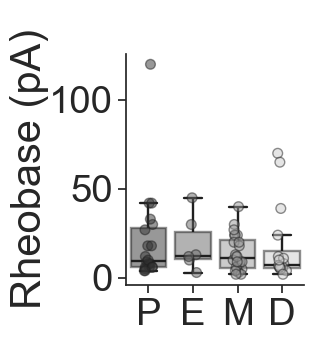

In [111]:
# rheobase

param = "rheobase_at_-60mV_(pA)"
ax = quick_plot(param, state_df)
ax.set_ylabel("Rheobase (pA)", labelpad=0)
plt.title(" ", pad=10)

Text(0, 0.5, 'AP halfwidth\n(ms)')

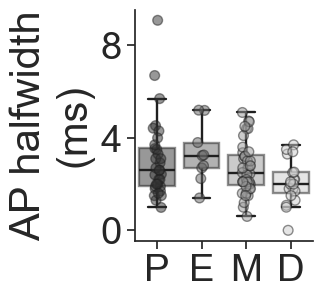

In [112]:
# rheobase

param = "AP_halfwidth"
ax = quick_plot(param, non_silent)
ax.set_ylabel("AP halfwidth\n(ms)", labelpad=5)


Text(0, 0.5, 'AP amplitude\n(mV)')

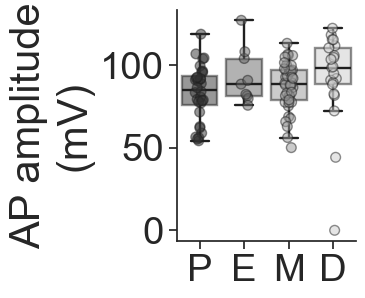

In [113]:
# rheobase

param = "AP_ampl"
ax = quick_plot(param, non_silent)
ax.set_ylabel("AP amplitude\n(mV)", labelpad=5)
# plt.title(" ", pad=10)


Text(0, 0.5, 'AHP (mV)')

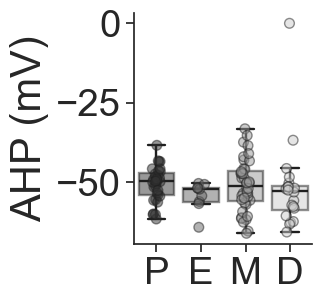

In [114]:
# rheobase

param = "AHP_(mV)"
ax = quick_plot(param, non_silent)
ax.set_ylabel("AHP (mV)", labelpad=5)
# plt.title(" ", pad=10)


Text(0, 0.5, 'CaT (mV)')

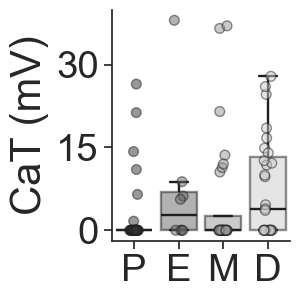

In [115]:
# rheobase

param = "CaT"
ax = quick_plot(param, state_df)
ax.set_ylabel("CaT (mV)", labelpad=5)
# plt.title(" ", pad=10)


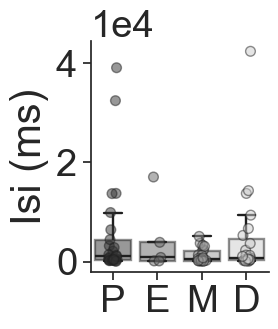

In [116]:
# Ih - estrous Pre
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")
param = "isi_(ms)"

non_silent = state_df[state_df.I_zero_reclassified != "silent"]
# non_silent = state_df
ax = sns.boxplot(
    x="estrous_stage",
    y=param,
    data=non_silent,
    order=["P", "E", "M", "D"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette="gray",
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="estrous_stage",
    y=param,
    data=non_silent,
    order=["P", "E", "M", "D"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette="gray",
    alpha=0.5,
)
ax.set_xlabel("")
ax.set_ylabel("Isi (ms)", labelpad=5)

ax.set_xticklabels(("P", "E", "M", "D"))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ticklabel_format(
    style="sci", axis="y", scilimits=(0, 0)
)  # scientific notation on y-axis


sns.despine(bottom=False, trim=False)



IH             no  yes  All
estrous_stage              
D               5   22   27
E               0    8    8
M              12   16   28
P               8   22   30
All            25   68   93
7.5382969187675055 0.05658256248491508 3


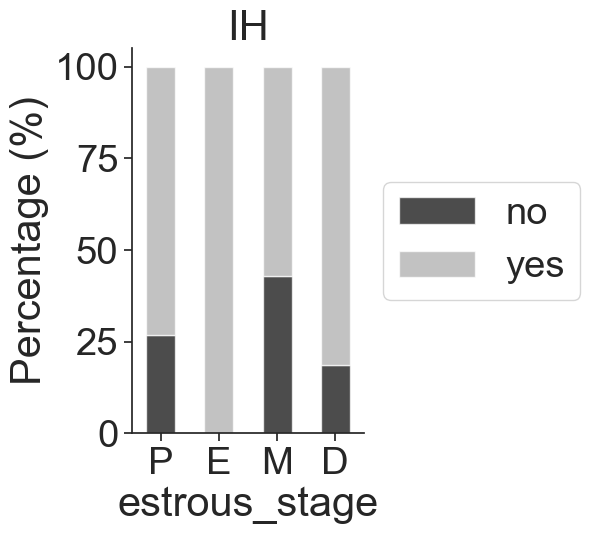

                            OLS Regression Results                            
Dep. Variable:                     no   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     7.084
Date:                Sat, 18 Oct 2025   Prob (F-statistic):            0.00838
Time:                        16:47:01   Log-Likelihood:                -862.66
No. Observations:                 211   AIC:                             1729.
Df Residuals:                     209   BIC:                             1736.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           22.7817      1.213  

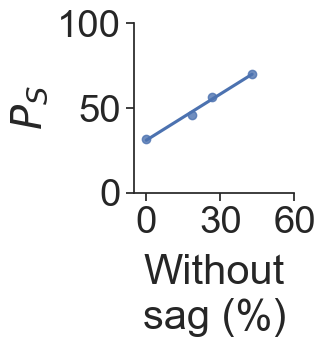

In [120]:
cols = ["no", "yes"]
ephys.loc[(ephys["Ih_at_-120mV"] == 0), "IH"] = "no"
ephys.loc[(ephys["Ih_at_-120mV"] > 0), "IH"] = "yes"


estrous_df = pd.read_csv(
    "data/estrous_data.csv"
)
estrous_df.rename(
    columns={"Unnamed: 0": "estrous_stage", "0": "switching probability"}, inplace=True
)
ephys_pre = ephys[ephys.Behaviour_6hFD == "Pre"]


raw = pd.read_csv(
    "../NPS_behaviour_analysis/data/negative_parental_switch_summary.csv", encoding="cp1252"
)
raw = raw[
    (raw["estrous_stage"].isin(["P", "E", "M", "D"]))
    & (raw["exp_cond"].isin(["all_stressor_5h", "food_deprivation"]))
]
raw = raw.loc[:, ["estrous_stage", "state_after"]]
raw["state_after"] = raw["state_after"].apply(lambda x: 1 if x == "Agg+" else 0)


for column in ["IH"]:  # cat_categ', 'IH', 'Adaptive'
    stat_ephys_pre = ephys_pre[ephys_pre.estrous_stage.isin(["P", "E", "M", "D"])]
    esprop = proportion(stat_ephys_pre, "estrous_stage", column, cols)
    esprop["estrous_stage"] = pd.Categorical(
        esprop["estrous_stage"], ["P", "E", "M", "D"]
    )
    esprop = esprop.sort_values(by=["estrous_stage"]).dropna()
    prop_plot(esprop, "estrous_stage")
    plt.title(column)
    plt.show()

    stats_df = raw.merge(esprop, on="estrous_stage")
    response_var = "state_after"
    formula = f'no ~ Q("{response_var}")'
    model = smf.ols(formula, data=stats_df).fit()
    print(model.summary())

    sns.set(font_scale=2.5)
    sns.set_style("ticks")
    sns.lmplot(
        x="no", y="switching probability", data=corr, ci=None, height=3.5, aspect=1
    )  # plt.xlabel(r'$\mathit{P}_{\mathit{S}}$')
    plt.ylim([0, 100])
    plt.xlim([-5, 60])
    plt.xticks([0, 30, 60])
    plt.xlabel("Without\nsag (%)", labelpad=10)  # plt.xlabel(f'% {column}')
    plt.ylabel(r"$\mathit{P}_{\mathit{S}}$")  # plt.ylabel('Switching probability(%)')
    #     plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/{column}_switching_corr.pdf',
    #             dpi=300,bbox_inches='tight', transparent=True)
    plt.show()

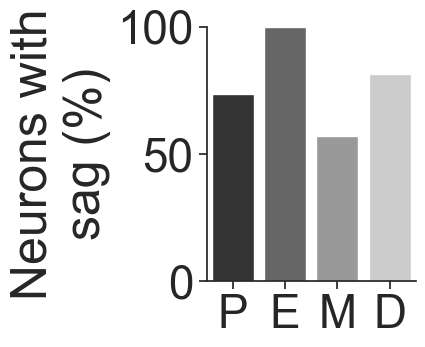

In [121]:
# Plot % of neurons that have Ih per estrous state
sns.set(rc={"figure.figsize": (2.7, 3.3)})
sns.set(font_scale=3)
sns.set_style("ticks")
sns.barplot(x="estrous_stage", y="yes", data=esprop, palette="gray")
plt.xlabel("")
plt.ylabel("Neurons with\nsag (%)")
plt.ylim(0, 100)
sns.despine(bottom=False)
# plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_9/linked_figure_S9/percent_sag_estrous.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

# NPY administration

In [43]:
ephys = pd.read_csv("data/sampled_ephys_data.csv")
ephys_npy = ephys.copy()
# ephys_npy['Behaviour_6hFD'] = ephys_npy['Behaviour_6hFD'].replace(['npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100'], 'npy')

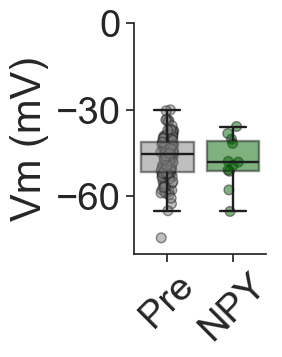

In [44]:
# Membrane voltage / RMP + NPY
ephys_npy.dropna(subset=["Vm"]).groupby("Behaviour_6hFD")["Vm"].describe()
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys_npy,
    order=["Pre", "npy_100"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=npy,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys_npy,
    order=["Pre", "npy_100"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=npy,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Vm (mV)", labelpad=5)

ax.set_xticklabels(("Pre", "NPY"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_npy.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

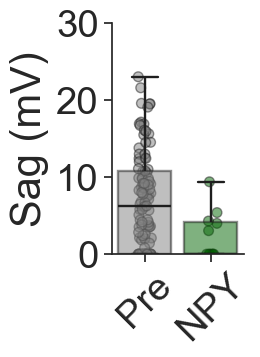

In [45]:
# Ih + NPY


sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys_npy,
    order=["Pre", "npy_100"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=npy,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys_npy,
    order=["Pre", "npy_100"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=npy,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Sag (mV)", labelpad=5)

ax.set_xticklabels(("Pre", "NPY"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_npy.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

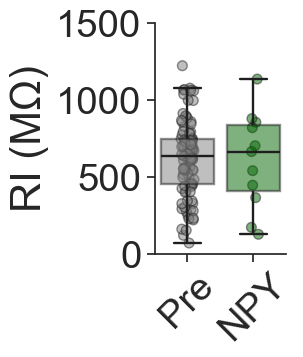

In [46]:
# RI + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys_npy,
    order=["Pre", "npy_100"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=npy,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys_npy,
    order=["Pre", "npy_100"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=npy,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("RI (MΩ)", labelpad=5)

ax.set_xticklabels(("Pre", "NPY"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_npy.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

In [ ]:
# Proportion of silent neurons
cols = ["silent", "phasic", "tonic"]
cat = ["Pre", "npy_100"]
silent_npy = proportion(
    ephys_npy[ephys_npy.Behaviour_6hFD.isin(cat)], "Behaviour_6hFD", "I_zero", cols
)
silent_npy["Behaviour_6hFD"] = pd.Categorical(silent_npy["Behaviour_6hFD"], cat)
silent_npy = silent_npy.sort_values(by=["Behaviour_6hFD"])

I_zero          phasic  phasic   silent  tonic  All
Behaviour_6hFD                                     
Pre                 22        1      33     70  126
npy_100              2        0       7      2   11
All                 24        1      40     72  137
7.637744508577842 0.054122857677496666 3


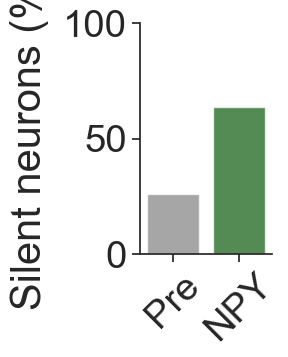

In [48]:
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_npy,
    x="Behaviour_6hFD",
    y="silent",
    order=["Pre", "npy_100"],
    palette=npy,
    alpha=0.7,
)
g.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylabel("Silent neurons (%)", labelpad=10)
g.set_xticklabels(("Pre", "NPY"), rotation=45)
plt.xlabel("")
plt.yticks(np.arange(0, 101, 50))
plt.ylim(0, 100)
# ax.yaxis.set_major_locator(plt.MaxNLocator(5))
sns.despine()
# plt.savefig(
#     # "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_npy.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

In [49]:
# subset df for those groups needed for firing freq. plot
ephys_npy_ff = ephys_npy.loc[
    (ephys_npy["Behaviour_6hFD"] == "Pre") | (ephys_npy["Behaviour_6hFD"] == "npy_100")
]

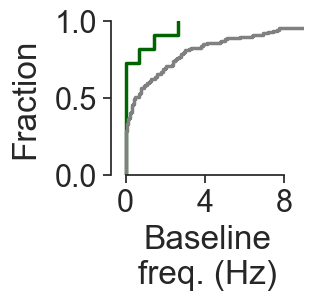

In [50]:
# Firing frequency
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2)
sns.set_style("ticks")

cum = sns.ecdfplot(
    data=ephys_npy_ff,
    x="Firing_freq_(Hz)_I0",
    hue="Behaviour_6hFD",
    palette=npy,
    linewidth=2.5,
    legend=False,
    stat="proportion",
)
cum.set_xlabel("Baseline\nfreq. (Hz)", labelpad=5)
cum.set_ylabel("Fraction", labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_npy.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

# AgRP administration

In [61]:
# reload data and convert all instances of AgRP application to 'agrp'
# UPDATE: use the updated agrp_100 column!
ephys = pd.read_csv("data/sampled_ephys_data.csv")
ephys_agrp = ephys.copy()
ephys_agrp["Behaviour_6hFD"] = ephys_agrp["Behaviour_6hFD"].replace(
    ["agrp_100_paired", "agrp_100"], "agrp"
)

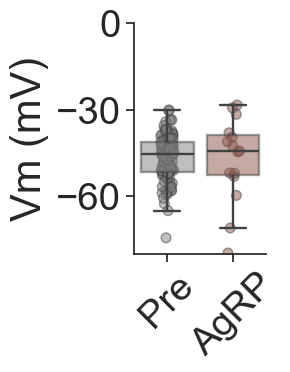

In [62]:
# Membrane voltage / RMP + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys_agrp,
    order=["Pre", "agrp"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=agrp,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=ephys_agrp,
    order=["Pre", "agrp"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=agrp,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Vm (mV)", labelpad=5)

ax.set_xticklabels(("Pre", "AgRP"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_agrp.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

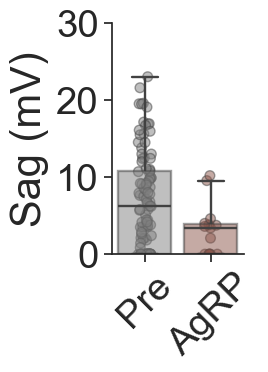

In [63]:
# Ih + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys_agrp,
    order=["Pre", "agrp"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=agrp,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys_agrp,
    order=["Pre", "agrp"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=agrp,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Sag (mV)", labelpad=5)

ax.set_xticklabels(("Pre", "AgRP"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_agrp.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

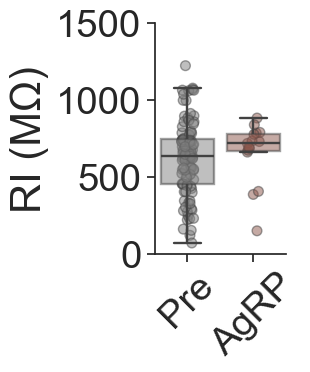

In [64]:
# RI + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys_agrp,
    order=["Pre", "agrp"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=agrp,
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=ephys_agrp,
    order=["Pre", "agrp"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=agrp,
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("RI (MΩ)", labelpad=5)

ax.set_xticklabels(("Pre", "AgRP"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_agrp.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

In [68]:
# Proportion of silent neurons
cols = ["silent", "phasic", "tonic"]
cat = ["Pre", "agrp"]

silent_agrp = proportion(
    ephys_agrp[ephys_agrp.Behaviour_6hFD.isin(cat)], "Behaviour_6hFD", "I_zero", cols
)
silent_agrp["Behaviour_6hFD"] = pd.Categorical(silent_agrp["Behaviour_6hFD"], cat)
silent_agrp = silent_agrp.sort_values(by=["Behaviour_6hFD"])

I_zero          phasic  phasic   silent  tonic  All
Behaviour_6hFD                                     
Pre                 22        1      33     70  126
agrp                 2        0       5      8   15
All                 24        1      38     78  141
0.5188998136366556 0.9147200126365818 3


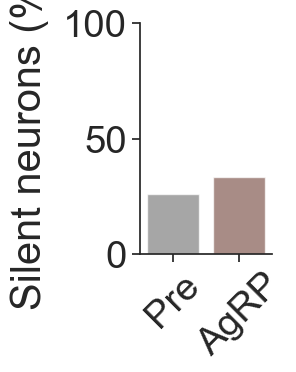

In [69]:
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

g = sns.barplot(
    silent_agrp,
    x="Behaviour_6hFD",
    y="silent",
    order=["Pre", "agrp"],
    palette=agrp,
    alpha=0.7,
)
g.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylabel("Silent neurons (%)", labelpad=10)
g.set_xticklabels(("Pre", "AgRP"), rotation=45)
plt.xlabel("")
plt.yticks(np.arange(0, 101, 50))
plt.ylim(0, 100)
sns.despine()
# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_agrp.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

In [70]:
# subset df for those groups needed for firing freq. plot
ephys_agrp_ff = ephys_agrp.loc[
    (ephys_agrp["Behaviour_6hFD"] == "Pre") | (ephys_agrp["Behaviour_6hFD"] == "agrp")
]

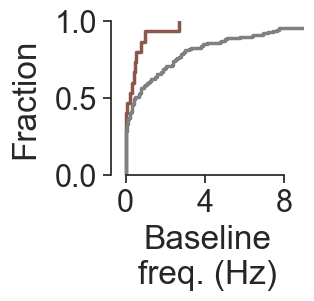

In [71]:
# Firing frequency
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2)
sns.set_style("ticks")

cum = sns.ecdfplot(
    data=ephys_agrp_ff,
    x="Firing_freq_(Hz)_I0",
    hue="Behaviour_6hFD",
    palette=agrp,
    linewidth=2.5,
    legend=False,
    stat="proportion",
)
cum.set_xlabel("Baseline\nfreq. (Hz)", labelpad=5)
cum.set_ylabel("Fraction", labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_agrp.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

# AgRPKD and NPYKD

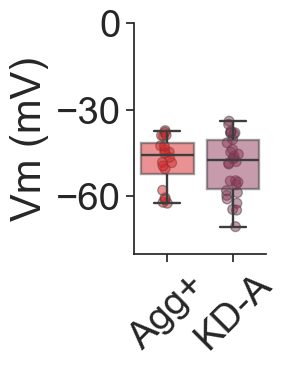

In [74]:
agrpkd_selected = ephys_agrp[
    (ephys_agrp["Behaviour_6hFD"].isin(["Agg+", "agrpkd"]))
    & (ephys_agrp.aggressive == "yes")
]

# Membrane voltage / RMP + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5)
sns.set_style("ticks")

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=agrpkd_selected,
    order=["Agg+", "agrpkd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=["Tab:red", "#8F3B5A"],
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Vm",
    data=agrpkd_selected,
    order=["Agg+", "agrpkd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=["Tab:red", "#8F3B5A"],
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Vm (mV)", labelpad=5)

ax.set_xticklabels(("Agg+", "KD-A"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_agrpkd.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

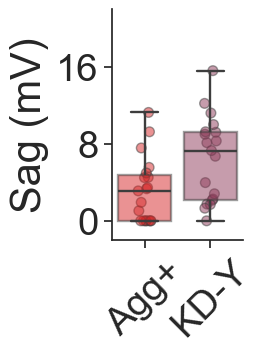

In [75]:
ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys_npy,
    order=["Agg+", "npykd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=["Tab:red", "#8F3B5A"],
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=ephys_npy,
    order=["Agg+", "npykd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=["Tab:red", "#8F3B5A"],
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Sag (mV)", labelpad=5)

ax.set_xticklabels(("Agg+", "KD-Y"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 22)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/Ih_npykd.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

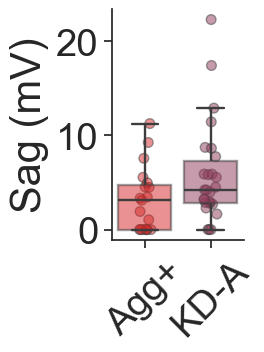

In [76]:
ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=agrpkd_selected,
    order=["Agg+", "agrpkd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=["Tab:red", "#8F3B5A"],
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Ih_at_-120mV",
    data=agrpkd_selected,
    order=["Agg+", "agrpkd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=["Tab:red", "#8F3B5A"],
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("Sag (mV)", labelpad=5)

ax.set_xticklabels(("Agg+", "KD-A"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
# plt.ylim(-2, 22)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_agrpkd.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

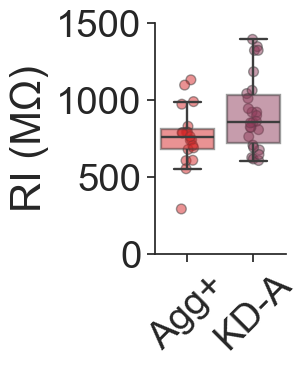

In [77]:

ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=agrpkd_selected,
    order=["Agg+", "agrpkd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=["Tab:red", "#8F3B5A"],
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="Input_Resistance",
    data=agrpkd_selected,
    order=["Agg+", "agrpkd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=["Tab:red", "#8F3B5A"],
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("RI (MΩ)", labelpad=5)

ax.set_xticklabels(("Agg+", "KD-A"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_agrpkd.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

I_zero_reclassified  active  silent  All
Behaviour_6hFD                          
Agg+                     11       9   20
npykd                    14       5   19
All                      25      14   39
0.7777274436090227 0.37783707063446803 1


Text(0.5, 1.0, ' ')

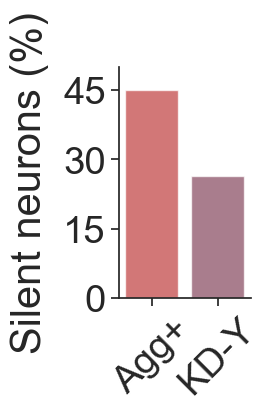

In [82]:
# Proportion of silent neurons
cols = ["silent", "active"]
cat = ["Agg+", "npykd"]
ephys_npy.loc[
    ephys_npy["I_zero_reclassified"].isin(["phasic", "tonic"]),
    "I_zero_reclassified",
] = "active"


silent_npy = proportion(
    ephys_npy[ephys_npy.Behaviour_6hFD.isin(cat)],
    "Behaviour_6hFD",
    "I_zero_reclassified",
    cols,
)
silent_npy["Behaviour_6hFD"] = pd.Categorical(silent_npy["Behaviour_6hFD"], cat)
silent_npy = silent_npy.sort_values(by=["Behaviour_6hFD"])


plt.subplots(figsize=(1.7, 3))
g = sns.barplot(
    silent_npy,
    x="Behaviour_6hFD",
    y="silent",
    order=["Agg+", "npykd"],
    palette=["Tab:red", "#8F3B5A"],
    alpha=0.7,
)
g.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylabel("Silent neurons (%)", labelpad=10)
g.set_xticklabels(("Agg+", "KD-Y"), rotation=45)
plt.xlabel("")
plt.yticks(np.arange(0, 101, 15))
plt.ylim(0, 50)
sns.despine()
plt.title(" ", pad=20)
# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_npykd.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

I_zero_reclassified  active  silent  All
Behaviour_6hFD                          
Agg+                     11       9   20
agrpkd                   20      11   31
All                      31      20   51
0.14889373048907378 0.6995947985155745 1


Text(0.5, 1.0, ' ')

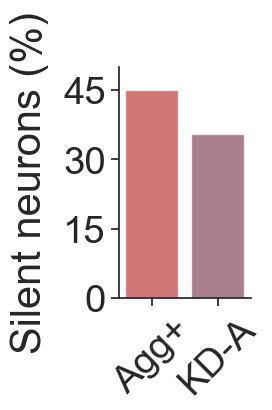

In [80]:
# Proportion of silent neurons
cols = ["silent", "active"]
cat = ["Agg+", "agrpkd"]
agrpkd_selected.loc[
    agrpkd_selected["I_zero_reclassified"].isin(["phasic", "tonic"]),
    "I_zero_reclassified",
] = "active"


silent_agrp = proportion(
    agrpkd_selected[agrpkd_selected.Behaviour_6hFD.isin(cat)],
    "Behaviour_6hFD",
    "I_zero_reclassified",
    cols,
)
silent_agrp["Behaviour_6hFD"] = pd.Categorical(silent_agrp["Behaviour_6hFD"], cat)
silent_agrp = silent_agrp.sort_values(by=["Behaviour_6hFD"])


plt.subplots(figsize=(1.7, 3))
g = sns.barplot(
    silent_agrp,
    x="Behaviour_6hFD",
    y="silent",
    order=["Agg+", "agrpkd"],
    palette=["Tab:red", "#8F3B5A"],
    alpha=0.7,
)
g.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylabel("Silent neurons (%)", labelpad=10)
g.set_xticklabels(("Agg+", "KD-A"), rotation=45)
plt.xlabel("")
plt.yticks(np.arange(0, 101, 15))
plt.ylim(0, 50)
sns.despine()
plt.title(" ", pad=20)
# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_agrpkd.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

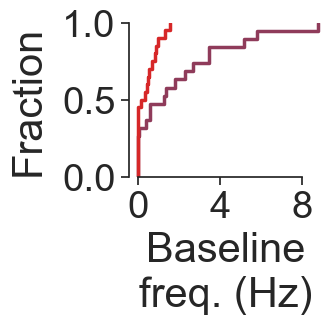

In [83]:
# npykd ff
plt.subplots(figsize=(2.5, 2.0))
cum = sns.ecdfplot(
    data=ephys_npy,
    x="Firing_freq_(Hz)_I0",
    hue="Behaviour_6hFD",
    hue_order=["Agg+", "npykd"],
    palette=["Tab:red", "#8F3B5A"],
    linewidth=2.5,
    legend=False,
    stat="proportion",
)
cum.set_xlabel("Baseline\nfreq. (Hz)", labelpad=5)
cum.set_ylabel("Fraction", labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/ff_npykd.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

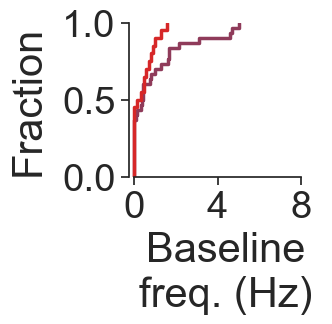

In [84]:
plt.subplots(figsize=(2.5, 2.0))
cum = sns.ecdfplot(
    data=agrpkd_selected,
    x="Firing_freq_(Hz)_I0",
    hue="Behaviour_6hFD",
    hue_order=["Agg+", "agrpkd"],
    palette=["Tab:red", "#8F3B5A"],
    linewidth=2.5,
    legend=False,
    stat="proportion",
)
cum.set_xlabel("Baseline\nfreq. (Hz)", labelpad=5)
cum.set_ylabel("Fraction", labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_agrpkd.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

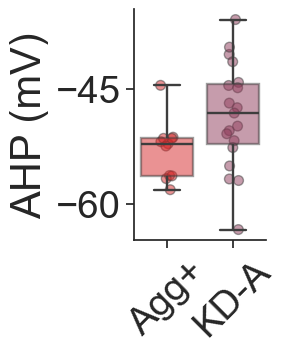

In [85]:
ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="AHP_(mV)",
    data=agrpkd_selected[agrpkd_selected["AHP_(mV)"] != 0],
    order=["Agg+", "agrpkd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=["Tab:red", "#8F3B5A"],
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="AHP_(mV)",
    data=agrpkd_selected[agrpkd_selected["AHP_(mV)"] != 0],
    order=["Agg+", "agrpkd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=["Tab:red", "#8F3B5A"],
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("AHP (mV)", labelpad=5)

ax.set_xticklabels(("Agg+", "KD-A"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
# plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)


# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ahp_agrpkd.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )

Text(0.5, 1.0, ' ')

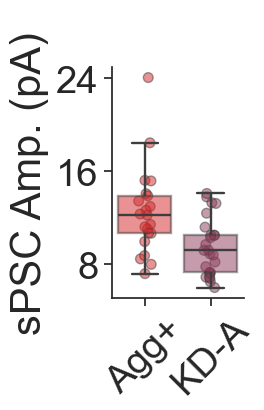

In [86]:
ax = sns.boxplot(
    x="Behaviour_6hFD",
    y="sPSC_Amplitude(pA)",
    data=agrpkd_selected,
    order=["Agg+", "agrpkd"],
    saturation=8,
    linewidth=1.7,
    showfliers=False,
    palette=["Tab:red", "#8F3B5A"],
    boxprops=dict(alpha=0.5),
)
ax = sns.stripplot(
    x="Behaviour_6hFD",
    y="sPSC_Amplitude(pA)",
    data=agrpkd_selected,
    order=["Agg+", "agrpkd"],
    jitter=True,
    dodge=False,
    marker="o",
    size=7,
    linewidth=1,
    edgecolor="gray",
    palette=["Tab:red", "#8F3B5A"],
    alpha=0.5,
    zorder=0,
)
ax.set_xlabel("")
ax.set_ylabel("sPSC Amp. (pA)", labelpad=5)

ax.set_xticklabels(("Agg+", "KD-A"), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
# plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)
plt.title(" ", pad=20)

# plt.savefig(
#     "/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/spsc_smplitude_agrpkd.pdf",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True,
# )